<a href="https://colab.research.google.com/github/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-/blob/main/Notebook_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# ANLOK Water Prediction Project — Notebook 5
## Final Model Analysis, Validation, Interpretation & Reporting

**Pipeline:** Notebook 1 → Notebook 2 → Notebook 3 → Notebook 4 → **Notebook 5**

This notebook is the final interpretation/reporting stage for the 2026 CSIT 3rd Year Artificial Intelligence / Data Science project.

### Source of truth
Notebook 4 is treated as the modelling source of truth. Notebook 5 does **not** invent new targets, fabricate metrics, silently replace failures with empty dataframes, or re-select a model using the final test set.

### Scientific scope
Notebook 4 established that the available project data supports a **water-service reliability regression problem** rather than verified event-level water-outage prediction.

The final model predicts:

`target_reliable_supply_pct`

derived from:

`population_reliable_supply_1`

and reports the decision-support proxy:

`predicted_outage_risk_proxy_pct = 100 - predicted_reliable_supply_pct`

This proxy must not be described as a direct probability of a future outage.

### Integrity rule
A critical Notebook 5 output is considered successful only when it:
- exists;
- is non-zero in size;
- contains required columns where applicable;
- contains at least one row for tabular outputs;
- contains finite prediction/metric values;
- is consistent with Notebook 4's saved artefacts.

If a critical result is empty or inconsistent, execution stops with an informative error.


## 1. Dependencies and reproducibility

Only standard data-science packages used by Notebook 4 are required. The cell checks the environment and installs a package only when it is missing.


In [1]:
# ============================================================
# 1. DEPENDENCIES AND REPRODUCIBILITY
# ============================================================

import importlib.util
import subprocess
import sys

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
}

missing_packages = [
    pip_name
    for module_name, pip_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Installing missing packages:", missing_packages)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages],
        check=True
    )

import base64
import json
import math
import os
import re
import warnings
from datetime import datetime, timezone
from getpass import getpass
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Dependencies ready.")
print("Random state:", RANDOM_STATE)


Dependencies ready.
Random state: 42


## 2. Project configuration

The paths below match Notebook 4's repository structure. Notebook 5 writes only to `Outputs/Results/` and does not overwrite Notebook 1–4 outputs.


In [2]:
# ============================================================
# 2. PROJECT CONFIGURATION
# ============================================================

REPO_NAME = "ANLOK-WATER-PREDICTION-PROJECT-"
GITHUB_REPO_URL = (
    "https://github.com/LulutheBA/"
    "ANLOK-WATER-PREDICTION-PROJECT-.git"
)

PROJECT_ROOT = Path("/content") / REPO_NAME

# Notebook 4 directories — exact project structure.
MODELS_DIR = PROJECT_ROOT / "Outputs" / "Models"
MODEL_EVALUATION_DIR = PROJECT_ROOT / "Outputs" / "ModelEvaluation"
PREDICTIONS_DIR = PROJECT_ROOT / "Outputs" / "Predictions"
MODEL_VISUALISATION_DIR = PROJECT_ROOT / "Outputs" / "ModelVisualisations"
MODEL_REPORTS_DIR = PROJECT_ROOT / "Outputs" / "ModelReports"
MODELLING_DATA_DIR = PROJECT_ROOT / "Outputs" / "ModellingData"

# Notebook 5 outputs.
RESULTS_DIR = PROJECT_ROOT / "Outputs" / "Results"
RESULTS_VIS_DIR = RESULTS_DIR / "Visualisations"

NOTEBOOK5_FILENAME = "NB5_Final_Analysis_Fixed.ipynb"

# Exact Notebook 4 artefacts used by Notebook 5.
NB4_PATHS = {
    "best_model": MODELS_DIR / "best_model.joblib",
    "model_comparison": MODEL_EVALUATION_DIR / "model_comparison_validation.csv",
    "final_test_metrics": MODEL_EVALUATION_DIR / "final_test_metrics.csv",
    "final_model_configuration": MODEL_EVALUATION_DIR / "final_model_configuration.json",
    "split_summary": MODEL_EVALUATION_DIR / "data_split_summary.csv",
    "permutation_importance": MODEL_EVALUATION_DIR / "permutation_importance.csv",
    "model_native_importance": MODEL_EVALUATION_DIR / "feature_importance.csv",
    "test_predictions": PREDICTIONS_DIR / "test_predictions.csv",
    "notebook4_summary": MODEL_REPORTS_DIR / "notebook4_summary.json",
    "modelling_table": MODELLING_DATA_DIR / "notebook4_reliability_modelling_table.csv",
}

# Critical inputs that cannot be invented or safely replaced.
CRITICAL_NB4_INPUTS = [
    "best_model",
    "model_comparison",
    "final_model_configuration",
    "modelling_table",
]

TARGET_COLUMN = "target_reliable_supply_pct"
RAW_TARGET_COLUMN = "population_reliable_supply_1"
ACTUAL_COLUMN = "actual_reliable_supply_pct"
PREDICTED_COLUMN = "predicted_reliable_supply_pct"
RISK_PROXY_COLUMN = "predicted_outage_risk_proxy_pct"
ERROR_COLUMN = "absolute_error"
GEO_KEY = "wsa_name"

STATUS = {
    "repository_connected": False,
    "nb4_outputs_detected": False,
    "final_model_loaded": False,
    "test_dataset_loaded": False,
    "model_evaluated": False,
    "model_comparison_completed": False,
    "error_analysis_completed": False,
    "feature_importance_generated": False,
    "final_predictions_saved": False,
    "visualisations_saved": False,
    "results_saved": False,
    "project_summary_generated": False,
    "git_commit_complete": False,
    "github_push_complete": False,
}

print("Project root:", PROJECT_ROOT)
print("Repository:", GITHUB_REPO_URL)
print("Notebook 5 output directory:", RESULTS_DIR)


Project root: /content/ANLOK-WATER-PREDICTION-PROJECT-
Repository: https://github.com/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-.git
Notebook 5 output directory: /content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/Results


## 3. Robust GitHub repository setup

This cell is safe to rerun. It does not blindly clone over an existing directory and never deletes the project folder.

Behaviour:
- clone only when the project directory does not exist;
- use the existing repository when `.git` is present;
- initialize/fetch safely if a non-empty project folder exists without `.git`;
- pull with `--ff-only` only when the working tree is clean;
- otherwise fetch without overwriting local work.


In [3]:
# ============================================================
# 3. ROBUST GITHUB REPOSITORY SETUP
# ============================================================

def run_process(args, cwd=None, check=False):
    result = subprocess.run(
        list(args),
        cwd=str(cwd) if cwd is not None else None,
        capture_output=True,
        text=True,
    )
    if check and result.returncode != 0:
        message = result.stderr.strip() or result.stdout.strip()
        raise RuntimeError(message)
    return result


def run_git(args, cwd=PROJECT_ROOT, check=False):
    return run_process(["git", *list(args)], cwd=cwd, check=check)


print("=" * 80)
print("NOTEBOOK 5 — GITHUB PROJECT CONNECTION")
print("=" * 80)

if not PROJECT_ROOT.exists():
    print("Project directory not found. Cloning repository...")
    clone = run_process(
        ["git", "clone", GITHUB_REPO_URL, str(PROJECT_ROOT)]
    )
    if clone.returncode != 0:
        raise RuntimeError(
            "GitHub clone failed.\n"
            + (clone.stderr.strip() or clone.stdout.strip())
        )

elif (PROJECT_ROOT / ".git").is_dir():
    print("Existing Git repository detected.")

else:
    existing_items = list(PROJECT_ROOT.iterdir())
    if not existing_items:
        print("Empty project directory detected. Cloning into it...")
        PROJECT_ROOT.rmdir()
        clone = run_process(
            ["git", "clone", GITHUB_REPO_URL, str(PROJECT_ROOT)]
        )
        if clone.returncode != 0:
            raise RuntimeError(
                "GitHub clone failed.\n"
                + (clone.stderr.strip() or clone.stdout.strip())
            )
    else:
        print(
            "WARNING: Project folder exists and contains files, "
            "but .git is missing."
        )
        print("Initialising Git metadata without deleting any project files.")

        init_result = run_process(["git", "init"], cwd=PROJECT_ROOT)
        if init_result.returncode != 0:
            raise RuntimeError(
                "Could not initialise Git repository.\n"
                + (init_result.stderr.strip() or init_result.stdout.strip())
            )

        remote_check = run_git(["remote", "get-url", "origin"])
        if remote_check.returncode == 0:
            run_git(["remote", "set-url", "origin", GITHUB_REPO_URL], check=True)
        else:
            run_git(["remote", "add", "origin", GITHUB_REPO_URL], check=True)

        fetch = run_git(["fetch", "origin", "main"])
        if fetch.returncode != 0:
            raise RuntimeError(
                "Could not fetch the GitHub repository.\n"
                + (fetch.stderr.strip() or fetch.stdout.strip())
            )

        checkout = run_git(["checkout", "-B", "main", "origin/main"])
        if checkout.returncode != 0:
            raise RuntimeError(
                "The existing non-Git folder conflicts with repository files. "
                "No files were deleted. Resolve the conflicting local files "
                "before continuing.\n"
                + (checkout.stderr.strip() or checkout.stdout.strip())
            )

# Ensure origin is always a safe URL without embedded credentials.
remote_check = run_git(["remote", "get-url", "origin"])
if remote_check.returncode == 0:
    current_remote = remote_check.stdout.strip()
    if current_remote != GITHUB_REPO_URL:
        print("Resetting origin to the credential-free repository URL.")
        run_git(["remote", "set-url", "origin", GITHUB_REPO_URL], check=True)
else:
    run_git(["remote", "add", "origin", GITHUB_REPO_URL], check=True)

# Update safely.
dirty = run_git(["status", "--porcelain"], check=True).stdout.strip()

if dirty:
    print(
        "Local changes detected. Running git fetch only so local work "
        "is not overwritten."
    )
    fetch = run_git(["fetch", "origin", "main"])
    if fetch.returncode != 0:
        raise RuntimeError(
            "Git fetch failed.\n"
            + (fetch.stderr.strip() or fetch.stdout.strip())
        )
else:
    pull = run_git(["pull", "--ff-only", "origin", "main"])
    if pull.returncode != 0:
        raise RuntimeError(
            "Git pull --ff-only failed. Resolve the repository state "
            "before continuing.\n"
            + (pull.stderr.strip() or pull.stdout.strip())
        )

# Create Notebook 5 output folders only after repository setup.
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_VIS_DIR.mkdir(parents=True, exist_ok=True)

git_root = run_git(["rev-parse", "--show-toplevel"], check=True).stdout.strip()
branch = run_git(["branch", "--show-current"], check=True).stdout.strip()
safe_remote = run_git(["remote", "get-url", "origin"], check=True).stdout.strip()

if Path(git_root).resolve() != PROJECT_ROOT.resolve():
    raise RuntimeError(
        f"Unexpected Git root: {git_root}\nExpected: {PROJECT_ROOT}"
    )

if safe_remote != GITHUB_REPO_URL:
    raise RuntimeError("Git remote validation failed.")

STATUS["repository_connected"] = True

print()
print("PASS: Repository connected.")
print("Git root:", git_root)
print("Branch:", branch)
print("Origin:", safe_remote)


NOTEBOOK 5 — GITHUB PROJECT CONNECTION
Project directory not found. Cloning repository...

PASS: Repository connected.
Git root: /content/ANLOK-WATER-PREDICTION-PROJECT-
Branch: main
Origin: https://github.com/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-.git


## 4. Notebook 4 output discovery and validation

This section audits Notebook 4's real artefacts before any final analysis is attempted.

It reports:
- available models;
- evaluation CSVs;
- prediction CSVs;
- reports/metadata;
- visualisations;
- file size;
- CSV row count;
- zero-byte files;
- empty CSV files;
- missing critical files.

`test_predictions.csv`, `final_test_metrics.csv`, and feature-importance outputs are recoverable because Notebook 5 can recompute them from the saved model and modelling table. The saved model, modelling table, model-comparison table, and final configuration are not fabricated if absent.


In [4]:
# ============================================================
# 4. NOTEBOOK 4 OUTPUT DISCOVERY AND VALIDATION
# ============================================================

def safe_csv_row_count(path):
    try:
        frame = pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return 0, "EMPTY"
    except Exception as exc:
        return None, f"READ_ERROR: {exc}"
    return len(frame), "PASS" if len(frame) > 0 else "EMPTY"


def inspect_file(path):
    path = Path(path)
    record = {
        "file": str(path.relative_to(PROJECT_ROOT))
        if PROJECT_ROOT in path.parents else str(path),
        "type": path.suffix.lower().lstrip(".").upper() or "FILE",
        "size_bytes": path.stat().st_size if path.exists() else 0,
        "rows": None,
        "status": "MISSING",
    }

    if not path.exists():
        return record

    if path.stat().st_size == 0:
        record["status"] = "EMPTY"
        if path.suffix.lower() == ".csv":
            record["rows"] = 0
        return record

    if path.suffix.lower() == ".csv":
        rows, status = safe_csv_row_count(path)
        record["rows"] = rows
        record["status"] = status
    else:
        record["status"] = "PASS"

    return record


nb4_directories = [
    MODELS_DIR,
    MODEL_EVALUATION_DIR,
    PREDICTIONS_DIR,
    MODEL_VISUALISATION_DIR,
    MODEL_REPORTS_DIR,
    MODELLING_DATA_DIR,
]

print("=" * 80)
print("NOTEBOOK 5 — NOTEBOOK 4 OUTPUT VALIDATION")
print("=" * 80)
print("Project root:", PROJECT_ROOT)

inventory_records = []

for directory in nb4_directories:
    print()
    print("Checking:", directory.relative_to(PROJECT_ROOT))
    if not directory.exists():
        print("  WARNING: directory not found.")
        continue

    files = sorted(p for p in directory.rglob("*") if p.is_file())
    print(f"  Files found: {len(files)}")

    for file_path in files:
        inventory_records.append(inspect_file(file_path))

nb4_inventory_df = pd.DataFrame(inventory_records)

if nb4_inventory_df.empty:
    raise RuntimeError(
        "No Notebook 4 artefacts were discovered in the expected project "
        "directories."
    )

display(
    nb4_inventory_df.sort_values(
        ["status", "file"],
        ascending=[True, True]
    ).reset_index(drop=True)
)

print()
print("Expected Notebook 4 artefacts:")
expected_records = []

for name, path in NB4_PATHS.items():
    record = inspect_file(path)
    record["artefact"] = name
    record["critical"] = name in CRITICAL_NB4_INPUTS
    expected_records.append(record)

expected_nb4_df = pd.DataFrame(expected_records)[
    ["artefact", "file", "critical", "type", "size_bytes", "rows", "status"]
]
display(expected_nb4_df)

critical_failures = expected_nb4_df[
    expected_nb4_df["critical"]
    & (expected_nb4_df["status"] != "PASS")
]

if not critical_failures.empty:
    raise RuntimeError(
        "Critical Notebook 4 artefacts are missing, empty, or unreadable:\n"
        + "\n".join(
            f"- {row['artefact']}: {row['file']} ({row['status']})"
            for _, row in critical_failures.iterrows()
        )
    )

zero_byte_files = nb4_inventory_df[
    nb4_inventory_df["size_bytes"] == 0
]

empty_csv_files = nb4_inventory_df[
    (nb4_inventory_df["type"] == "CSV")
    & (nb4_inventory_df["rows"] == 0)
]

print()
print("Zero-byte files detected:", len(zero_byte_files))
print("CSV files with zero rows:", len(empty_csv_files))
print("Critical Notebook 4 inputs: PASS")

STATUS["nb4_outputs_detected"] = True


NOTEBOOK 5 — NOTEBOOK 4 OUTPUT VALIDATION
Project root: /content/ANLOK-WATER-PREDICTION-PROJECT-

Checking: Outputs/Models
  Files found: 3

Checking: Outputs/ModelEvaluation
  Files found: 22

Checking: Outputs/Predictions
  Files found: 2

Checking: Outputs/ModelVisualisations
  Files found: 13

Checking: Outputs/ModelReports
  Files found: 4

Checking: Outputs/ModellingData
  Files found: 20


,file,type,size_bytes,rows,status
0,Outputs/ModelEvaluation/baseline_model_compari...,CSV,479,5.0,PASS
1,Outputs/ModelEvaluation/cross_validation_resul...,CSV,845,6.0,PASS
2,Outputs/ModelEvaluation/data_split_summary.csv,CSV,122,3.0,PASS
3,Outputs/ModelEvaluation/feature_category_audit...,CSV,26158,116.0,PASS
4,Outputs/ModelEvaluation/feature_correlation_pa...,CSV,4807,55.0,PASS
...,...,...,...,...,...
59,Outputs/Models/Blank.pdf,PDF,1,NaN,PASS
60,Outputs/Models/Weather_engineered_rainfall_7da...,JOBLIB,11962,NaN,PASS
61,Outputs/Models/best_model.joblib,JOBLIB,824323,NaN,PASS
62,Outputs/Predictions/gauteng_municipality_predi...,CSV,592,9.0,PASS



Expected Notebook 4 artefacts:


,artefact,file,critical,type,size_bytes,rows,status
0,best_model,Outputs/Models/best_model.joblib,True,JOBLIB,824323,NaN,PASS
1,model_comparison,Outputs/ModelEvaluation/model_comparison_valid...,True,CSV,644,6.0,PASS
2,final_test_metrics,Outputs/ModelEvaluation/final_test_metrics.csv,False,CSV,130,1.0,PASS
3,final_model_configuration,Outputs/ModelEvaluation/final_model_configurat...,True,JSON,1840,NaN,PASS
4,split_summary,Outputs/ModelEvaluation/data_split_summary.csv,False,CSV,122,3.0,PASS
5,permutation_importance,Outputs/ModelEvaluation/permutation_importance...,False,CSV,799,12.0,PASS
6,model_native_importance,Outputs/ModelEvaluation/feature_importance.csv,False,CSV,6014,142.0,PASS
7,test_predictions,Outputs/Predictions/test_predictions.csv,False,CSV,4817,22.0,PASS
8,notebook4_summary,Outputs/ModelReports/notebook4_summary.json,False,JSON,1591,NaN,PASS
9,modelling_table,Outputs/ModellingData/notebook4_reliability_mo...,True,CSV,22495,144.0,PASS



Zero-byte files detected: 0
CSV files with zero rows: 0
Critical Notebook 4 inputs: PASS


## 5. Load and validate Notebook 4 metadata and tabular inputs

The loaders below never replace a failed read with `pd.DataFrame()`. Required columns and non-empty row counts are checked immediately.


In [5]:
# ============================================================
# 5. LOAD AND VALIDATE NOTEBOOK 4 INPUTS
# ============================================================

def load_required_csv(path, required_columns=None, label=None):
    path = Path(path)
    label = label or path.name

    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")

    if path.stat().st_size == 0:
        raise ValueError(f"Required file is zero bytes: {path}")

    try:
        df = pd.read_csv(path)
    except pd.errors.EmptyDataError as exc:
        raise ValueError(f"CSV contains no readable data: {path}") from exc

    if df is None:
        raise ValueError(f"{label} dataframe was not created.")

    if df.empty:
        raise ValueError(
            f"{label} is empty after loading. File: {path}"
        )

    if required_columns:
        missing_columns = [
            col for col in required_columns if col not in df.columns
        ]
        if missing_columns:
            raise ValueError(
                f"{label} is missing required columns: {missing_columns}\n"
                f"Available columns: {df.columns.tolist()}"
            )

    print(
        f"PASS: {label} — rows={len(df):,}, "
        f"columns={len(df.columns):,}"
    )
    return df


def load_optional_csv(path, required_columns=None, label=None):
    path = Path(path)
    label = label or path.name

    if not path.exists() or path.stat().st_size == 0:
        print(f"WARNING: {label} unavailable or zero bytes: {path}")
        return None

    try:
        df = pd.read_csv(path)
    except Exception as exc:
        print(f"WARNING: Could not read {label}: {exc}")
        return None

    if df.empty:
        print(f"WARNING: {label} contains zero rows.")
        return None

    if required_columns:
        missing = [c for c in required_columns if c not in df.columns]
        if missing:
            print(
                f"WARNING: {label} is missing required columns: {missing}"
            )
            return None

    return df


def load_required_json(path, required_keys=None, label=None):
    path = Path(path)
    label = label or path.name

    if not path.exists():
        raise FileNotFoundError(f"Required JSON not found: {path}")

    if path.stat().st_size == 0:
        raise ValueError(f"Required JSON is zero bytes: {path}")

    with open(path, "r", encoding="utf-8") as handle:
        data = json.load(handle)

    if not isinstance(data, dict) or not data:
        raise ValueError(f"{label} did not contain a non-empty JSON object.")

    if required_keys:
        missing = [key for key in required_keys if key not in data]
        if missing:
            raise ValueError(
                f"{label} is missing required keys: {missing}"
            )

    print(f"PASS: {label}")
    return data


final_config = load_required_json(
    NB4_PATHS["final_model_configuration"],
    required_keys=[
        "problem_type",
        "model_target",
        "raw_target_column",
        "best_model",
        "test_rows",
        "final_test_metrics",
    ],
    label="Notebook 4 final model configuration",
)

if final_config["problem_type"] != "regression":
    raise ValueError(
        "Notebook 5 expected a regression problem because Notebook 4 "
        f"defines problem_type={final_config['problem_type']!r}."
    )

if final_config["model_target"] != TARGET_COLUMN:
    raise ValueError(
        "Notebook 4 target mismatch. "
        f"Expected {TARGET_COLUMN!r}, found "
        f"{final_config['model_target']!r}."
    )

if final_config["raw_target_column"] != RAW_TARGET_COLUMN:
    raise ValueError(
        "Notebook 4 source-target mismatch. "
        f"Expected {RAW_TARGET_COLUMN!r}, found "
        f"{final_config['raw_target_column']!r}."
    )

model_comparison_df = load_required_csv(
    NB4_PATHS["model_comparison"],
    required_columns=["model", "split", "MAE", "RMSE", "R2"],
    label="Notebook 4 validation model comparison",
)

modelling_table_df = load_required_csv(
    NB4_PATHS["modelling_table"],
    required_columns=[TARGET_COLUMN],
    label="Notebook 4 modelling table",
)

split_summary_df = load_optional_csv(
    NB4_PATHS["split_summary"],
    required_columns=["split", "rows"],
    label="Notebook 4 split summary",
)

saved_test_metrics_df = load_optional_csv(
    NB4_PATHS["final_test_metrics"],
    required_columns=["model", "MAE", "RMSE", "R2"],
    label="Notebook 4 final test metrics",
)

saved_predictions_df = load_optional_csv(
    NB4_PATHS["test_predictions"],
    required_columns=[ACTUAL_COLUMN, PREDICTED_COLUMN],
    label="Notebook 4 saved test predictions",
)

print()
print("Notebook 4 configuration:")
print("  Problem type:", final_config["problem_type"])
print("  Source target:", final_config["raw_target_column"])
print("  Model target:", final_config["model_target"])
print("  Best model:", final_config["best_model"])
print("  Total observations:", final_config.get("total_observations"))
print("  Train rows:", final_config.get("training_rows"))
print("  Validation rows:", final_config.get("validation_rows"))
print("  Test rows:", final_config.get("test_rows"))
print("  True event-level outage target:",
      final_config.get("true_outage_target_available"))

if final_config.get("true_outage_target_available") is not False:
    print(
        "WARNING: Notebook 4 metadata no longer explicitly marks the "
        "event-level outage target as unavailable. Review the scientific "
        "scope before presenting."
    )


PASS: Notebook 4 final model configuration
PASS: Notebook 4 validation model comparison — rows=6, columns=6
PASS: Notebook 4 modelling table — rows=144, columns=13

Notebook 4 configuration:
  Problem type: regression
  Source target: population_reliable_supply_1
  Model target: target_reliable_supply_pct
  Best model: Extra Trees
  Total observations: 144
  Train rows: 100
  Validation rows: 22
  Test rows: 22
  True event-level outage target: False


## 6. Load the saved final model

Notebook 4 saved the complete fitted scikit-learn pipeline as `Outputs/Models/best_model.joblib`. Because preprocessing is inside the pipeline, Notebook 5 must pass predictors in the same raw feature schema/order rather than manually re-scaling data.


In [6]:
# ============================================================
# 6. LOAD SAVED FINAL MODEL
# ============================================================

model_path = NB4_PATHS["best_model"]

if not model_path.exists():
    raise FileNotFoundError(f"Required model not found: {model_path}")

if model_path.stat().st_size == 0:
    raise ValueError(f"Saved model is zero bytes: {model_path}")

try:
    best_model = joblib.load(model_path)
except Exception as exc:
    raise RuntimeError(
        f"Failed to load Notebook 4 model: {model_path}\n{exc}"
    ) from exc

if not hasattr(best_model, "predict"):
    raise TypeError(
        "Loaded Notebook 4 artefact does not expose a predict() method."
    )

model_steps = (
    list(best_model.named_steps.keys())
    if hasattr(best_model, "named_steps")
    else []
)

STATUS["final_model_loaded"] = True

print("PASS: Final model loaded.")
print("Model name:", final_config["best_model"])
print("Python object type:", type(best_model).__name__)
print("Pipeline steps:", model_steps if model_steps else "Not exposed")
print("Model file size:", f"{model_path.stat().st_size / 1024:.1f} KB")


PASS: Final model loaded.
Model name: Extra Trees
Python object type: Pipeline
Pipeline steps: ['preprocessor', 'model']
Model file size: 805.0 KB


## 7. Reconstruct the untouched test set

Notebook 5 rebuilds the exact Notebook 4 final-test split from the saved modelling table using Notebook 4's split rule:

- random state = 42;
- 15% final test set;
- quantile-bin stratification when valid.

Only the final test split is reconstructed here. No model is retrained and no test result is used to choose a model.


In [7]:
# ============================================================
# 7. RECONSTRUCT NOTEBOOK 4 FINAL TEST SET
# ============================================================

def make_target_bins(y_values, max_bins=5):
    try:
        q = min(max_bins, int(y_values.nunique()))
        if q < 2:
            return None

        bins = pd.qcut(
            y_values,
            q=q,
            duplicates="drop",
        )

        if bins.nunique() >= 2:
            return bins

    except (ValueError, TypeError) as exc:
        print(
            "INFO: Quantile stratification unavailable; "
            f"falling back to unstratified split. Reason: {exc}"
        )

    return None


if modelling_table_df[TARGET_COLUMN].isna().any():
    missing_target_rows = int(
        modelling_table_df[TARGET_COLUMN].isna().sum()
    )
    raise ValueError(
        f"Modelling table contains {missing_target_rows} missing target "
        "values. Notebook 5 will not silently drop them."
    )

X_full = modelling_table_df.drop(columns=[TARGET_COLUMN]).copy()
y_full = pd.to_numeric(
    modelling_table_df[TARGET_COLUMN],
    errors="raise"
).astype(float)

if X_full.empty:
    raise ValueError("Predictor dataframe is empty.")

if len(X_full) != len(y_full):
    raise ValueError("Predictor/target row counts do not match.")

if not np.isfinite(y_full.to_numpy()).all():
    raise ValueError("Target contains NaN or infinite values.")

target_bins = make_target_bins(y_full)

split_kwargs = dict(
    test_size=0.15,
    random_state=RANDOM_STATE,
)

if target_bins is not None:
    split_kwargs["stratify"] = target_bins

X_train_val_rebuilt, X_test_rebuilt, y_train_val_rebuilt, y_test_rebuilt = (
    train_test_split(
        X_full,
        y_full,
        **split_kwargs,
    )
)

expected_test_rows = int(final_config["test_rows"])

if len(X_test_rebuilt) != expected_test_rows:
    raise RuntimeError(
        "Rebuilt final test row count does not match Notebook 4 metadata. "
        f"Expected {expected_test_rows}, got {len(X_test_rebuilt)}."
    )

# Validate feature schema against the fitted pipeline.
model_feature_names = getattr(best_model, "feature_names_in_", None)

if model_feature_names is None and hasattr(best_model, "named_steps"):
    preprocessor = best_model.named_steps.get("preprocessor")
    if preprocessor is not None:
        model_feature_names = getattr(
            preprocessor,
            "feature_names_in_",
            None,
        )

if model_feature_names is not None:
    model_feature_names = list(model_feature_names)

    missing_features = [
        feature
        for feature in model_feature_names
        if feature not in X_test_rebuilt.columns
    ]

    extra_features = [
        feature
        for feature in X_test_rebuilt.columns
        if feature not in model_feature_names
    ]

    if missing_features:
        raise ValueError(
            "The reconstructed test set is missing features required by "
            f"the fitted model: {missing_features}"
        )

    if extra_features:
        print(
            "INFO: Reconstructed table contains extra columns not used by "
            f"the model: {extra_features}"
        )

    X_test_for_model = X_test_rebuilt[
        model_feature_names
    ].copy()
else:
    X_test_for_model = X_test_rebuilt.copy()

STATUS["test_dataset_loaded"] = True

print("=" * 80)
print("RECONSTRUCTED DATA SPLIT")
print("=" * 80)
print("Total rows:", len(X_full))
print("Train + validation rows:", len(X_train_val_rebuilt))
print("Final test rows:", len(X_test_for_model))
print("Predictors:", X_test_for_model.shape[1])
print("Target missing values:", int(y_test_rebuilt.isna().sum()))
print("Predictor columns:")
for idx, column in enumerate(X_test_for_model.columns, 1):
    print(f"  {idx:02d}. {column}")


RECONSTRUCTED DATA SPLIT
Total rows: 144
Train + validation rows: 122
Final test rows: 22
Predictors: 12
Target missing values: 0
Predictor columns:
  01. wsa_name
  02. population
  03. population_with_access_to_water
  04. urban_population
  05. urban_population_with_access_to_water
  06. rural_population
  07. rural_population_with_access_to_water
  08. log_population
  09. water_access_rate_pct
  10. water_access_gap_pct
  11. urban_population_share_pct
  12. rural_population_share_pct


## 8. Recompute and validate final predictions

This is the key repair against blank Notebook 5 outputs.

Notebook 5:
1. predicts directly with Notebook 4's fitted pipeline;
2. checks prediction count;
3. checks for NaN/infinite predictions;
4. reconstructs the final prediction table;
5. compares the recomputed predictions to Notebook 4's saved `test_predictions.csv` when that file is usable;
6. uses recomputed real predictions if the saved prediction CSV is missing or invalid.

No random/sample predictions are created.


In [8]:
# ============================================================
# 8. RECOMPUTE AND VALIDATE FINAL PREDICTIONS
# ============================================================

try:
    rebuilt_y_pred = np.asarray(
        best_model.predict(X_test_for_model),
        dtype=float,
    ).reshape(-1)
except Exception as exc:
    raise RuntimeError(
        "Prediction failed using Notebook 4's saved pipeline and rebuilt "
        f"test set.\n{exc}"
    ) from exc

if len(rebuilt_y_pred) == 0:
    raise ValueError("Expected prediction array is empty.")

if len(rebuilt_y_pred) != len(y_test_rebuilt):
    raise ValueError(
        "Prediction count does not match y_test. "
        f"Predictions={len(rebuilt_y_pred)}, "
        f"y_test={len(y_test_rebuilt)}"
    )

if not np.isfinite(rebuilt_y_pred).all():
    raise ValueError(
        "Predictions contain NaN or infinite values."
    )

rebuilt_predictions_df = X_test_rebuilt.copy()
rebuilt_predictions_df[ACTUAL_COLUMN] = y_test_rebuilt.to_numpy()
rebuilt_predictions_df[PREDICTED_COLUMN] = rebuilt_y_pred
rebuilt_predictions_df[RISK_PROXY_COLUMN] = 100.0 - rebuilt_y_pred
rebuilt_predictions_df["residual"] = (
    rebuilt_predictions_df[ACTUAL_COLUMN]
    - rebuilt_predictions_df[PREDICTED_COLUMN]
)
rebuilt_predictions_df[ERROR_COLUMN] = np.abs(
    rebuilt_predictions_df["residual"]
)

if rebuilt_predictions_df.empty:
    raise ValueError("Reconstructed prediction dataframe is empty.")

# Validate saved Notebook 4 predictions when available.
saved_predictions_match = False

if saved_predictions_df is not None:
    saved = saved_predictions_df.copy()

    essential = [ACTUAL_COLUMN, PREDICTED_COLUMN]

    if saved[essential].isna().any().any():
        print(
            "WARNING: Saved Notebook 4 prediction file contains missing "
            "actual/predicted values. Recomputed predictions will be used."
        )
    else:
        saved_numeric = saved[essential].apply(
            pd.to_numeric,
            errors="coerce"
        )

        if not np.isfinite(saved_numeric.to_numpy()).all():
            print(
                "WARNING: Saved prediction file contains non-finite "
                "values. Recomputed predictions will be used."
            )
        elif len(saved) != len(rebuilt_predictions_df):
            print(
                "WARNING: Saved prediction row count differs from the "
                "reconstructed final test set. Recomputed predictions "
                "will be used."
            )
        else:
            if (
                GEO_KEY in saved.columns
                and GEO_KEY in rebuilt_predictions_df.columns
                and saved[GEO_KEY].is_unique
                and rebuilt_predictions_df[GEO_KEY].is_unique
            ):
                comparison = saved[
                    [GEO_KEY, ACTUAL_COLUMN, PREDICTED_COLUMN]
                ].merge(
                    rebuilt_predictions_df[
                        [GEO_KEY, ACTUAL_COLUMN, PREDICTED_COLUMN]
                    ],
                    on=GEO_KEY,
                    suffixes=("_saved", "_rebuilt"),
                    how="inner",
                    validate="one_to_one",
                )

                if len(comparison) != len(rebuilt_predictions_df):
                    raise RuntimeError(
                        "Saved and rebuilt prediction files do not contain "
                        "the same final-test municipalities/service areas."
                    )

                actual_diff = np.max(np.abs(
                    comparison[f"{ACTUAL_COLUMN}_saved"]
                    - comparison[f"{ACTUAL_COLUMN}_rebuilt"]
                ))

                pred_diff = np.max(np.abs(
                    comparison[f"{PREDICTED_COLUMN}_saved"]
                    - comparison[f"{PREDICTED_COLUMN}_rebuilt"]
                ))
            else:
                actual_diff = np.max(np.abs(
                    saved_numeric[ACTUAL_COLUMN].to_numpy()
                    - rebuilt_predictions_df[ACTUAL_COLUMN].to_numpy()
                ))

                pred_diff = np.max(np.abs(
                    saved_numeric[PREDICTED_COLUMN].to_numpy()
                    - rebuilt_predictions_df[PREDICTED_COLUMN].to_numpy()
                ))

            tolerance = 1e-8

            if actual_diff > tolerance or pred_diff > tolerance:
                raise RuntimeError(
                    "Notebook 4 saved predictions are inconsistent with "
                    "the saved model + reconstructed test split.\n"
                    f"Max actual difference: {actual_diff}\n"
                    f"Max prediction difference: {pred_diff}"
                )

            saved_predictions_match = True
            print(
                "PASS: Saved Notebook 4 predictions match predictions "
                "recomputed from the fitted pipeline."
            )

canonical_predictions_df = rebuilt_predictions_df.copy()

STATUS["model_evaluated"] = True

print()
print("Prediction count:", len(canonical_predictions_df))
print(
    "Finite predictions:",
    bool(np.isfinite(
        canonical_predictions_df[PREDICTED_COLUMN].to_numpy()
    ).all())
)
print(
    "Saved Notebook 4 prediction file validated:",
    saved_predictions_match
)
display(
    canonical_predictions_df[
        [
            c for c in [
                GEO_KEY,
                ACTUAL_COLUMN,
                PREDICTED_COLUMN,
                RISK_PROXY_COLUMN,
                ERROR_COLUMN,
            ]
            if c in canonical_predictions_df.columns
        ]
    ].head(10)
)


PASS: Saved Notebook 4 predictions match predictions recomputed from the fitted pipeline.

Prediction count: 22
Finite predictions: True
Saved Notebook 4 prediction file validated: True


,wsa_name,actual_reliable_supply_pct,predicted_reliable_supply_pct,predicted_outage_risk_proxy_pct,absolute_error
27,Ngwathe,70.0,77.192660,22.807340,7.192660
92,Rustenburg,69.0,76.972189,23.027811,7.972189
93,!Kheis,62.0,73.851218,26.148782,11.851218
115,Thembelihle,84.0,75.216255,24.783745,8.783745
95,Dikgatlong,81.0,75.246608,24.753392,5.753392
117,Ubuntu,84.0,74.396804,25.603196,9.603196
24,Mohokare,46.0,77.163207,22.836793,31.163207
9,Makana,77.0,74.848093,25.151907,2.151907
63,Sekhukhune,37.0,35.824094,64.175906,1.175906
137,Prince Albert,89.0,77.318847,22.681153,11.681153


## 9. Final regression metrics and Notebook 4 consistency check

The final test set is used only to report the already-selected Notebook 4 model.

Appropriate regression metrics:
- **MAE** — average absolute error in reliability percentage points;
- **RMSE** — penalises larger prediction errors more strongly;
- **R²** — proportion of held-out target variance represented by the model relative to a mean baseline;
- **MAPE** — reported only because all final-test actual reliability values are non-zero.

Classification metrics such as accuracy, precision, recall, F1, and ROC-AUC are intentionally not used.


In [9]:
# ============================================================
# 9. FINAL REGRESSION METRICS
# ============================================================

y_true = canonical_predictions_df[ACTUAL_COLUMN].to_numpy(dtype=float)
y_pred = canonical_predictions_df[PREDICTED_COLUMN].to_numpy(dtype=float)

if len(y_true) == 0 or len(y_pred) == 0:
    raise ValueError("Metric inputs are empty.")

if len(y_true) != len(y_pred):
    raise ValueError("Metric input lengths differ.")

if not np.isfinite(y_true).all() or not np.isfinite(y_pred).all():
    raise ValueError("Metric inputs contain NaN or infinite values.")

final_mae = float(mean_absolute_error(y_true, y_pred))
final_mse = float(mean_squared_error(y_true, y_pred))
final_rmse = float(math.sqrt(final_mse))
final_r2 = float(r2_score(y_true, y_pred))

if np.any(y_true == 0):
    final_mape = None
    print(
        "MAPE not calculated because the final test target contains zero."
    )
else:
    final_mape = float(
        np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0
    )

calculated_metrics = {
    "MAE": final_mae,
    "MSE": final_mse,
    "RMSE": final_rmse,
    "R2": final_r2,
    "MAPE_pct": final_mape,
}

print("=" * 80)
print("FINAL TEST METRICS — RECOMPUTED FROM REAL PREDICTIONS")
print("=" * 80)
for metric, value in calculated_metrics.items():
    if value is not None:
        print(f"{metric}: {value:.6f}")
    else:
        print(f"{metric}: NOT APPLICABLE")

# Compare against Notebook 4 saved final-test metrics if available.
if saved_test_metrics_df is not None:
    saved_row = saved_test_metrics_df.iloc[0]

    comparison_fields = ["MAE", "RMSE", "R2"]
    if "MAPE_pct" in saved_test_metrics_df.columns and final_mape is not None:
        comparison_fields.append("MAPE_pct")

    metric_differences = {}

    for field in comparison_fields:
        saved_value = float(saved_row[field])
        current_value = float(calculated_metrics[field])
        metric_differences[field] = abs(saved_value - current_value)

    max_metric_diff = max(metric_differences.values())

    if max_metric_diff > 1e-8:
        raise RuntimeError(
            "Recomputed final-test metrics do not match Notebook 4's "
            "saved final-test metrics.\n"
            f"Differences: {metric_differences}"
        )

    print()
    print("PASS: Recomputed metrics match Notebook 4 final_test_metrics.csv.")

config_metrics = final_config.get("final_test_metrics", {})

for field in ["MAE", "RMSE", "R2"]:
    if field in config_metrics:
        difference = abs(
            float(config_metrics[field])
            - float(calculated_metrics[field])
        )
        if difference > 1e-8:
            raise RuntimeError(
                f"Metric {field} conflicts with final_model_configuration.json."
            )

print("PASS: Final metrics are internally consistent.")


FINAL TEST METRICS — RECOMPUTED FROM REAL PREDICTIONS
MAE: 7.856324
MSE: 106.457300
RMSE: 10.317815
R2: 0.553584
MAPE_pct: 11.756575

PASS: Recomputed metrics match Notebook 4 final_test_metrics.csv.
PASS: Final metrics are internally consistent.


## 10. Model comparison

Notebook 4 deliberately selected the model using validation performance and evaluated only the selected final model on the untouched test set.

Therefore:
- the **all-model comparison** below is a validation comparison;
- the **final test metrics** belong only to the selected final model;
- Notebook 5 does not test every model on the final test set, because doing so would turn the test set into another model-selection set.


In [10]:
# ============================================================
# 10. MODEL COMPARISON
# ============================================================

comparison_numeric_columns = ["MAE", "RMSE", "R2"]

for column in comparison_numeric_columns:
    model_comparison_df[column] = pd.to_numeric(
        model_comparison_df[column],
        errors="raise",
    )

if model_comparison_df[comparison_numeric_columns].isna().any().any():
    raise ValueError("Model comparison contains NaN metrics.")

if not np.isfinite(
    model_comparison_df[comparison_numeric_columns].to_numpy()
).all():
    raise ValueError("Model comparison contains infinite metrics.")

if (model_comparison_df["split"].astype(str) != "validation").any():
    raise ValueError(
        "Expected Notebook 4 all-model comparison to use validation data."
    )

model_comparison_final_df = (
    model_comparison_df
    .sort_values("RMSE", ascending=True)
    .reset_index(drop=True)
    .copy()
)

model_comparison_final_df["selection_stage"] = "validation"
model_comparison_final_df["rank_by_RMSE"] = (
    np.arange(1, len(model_comparison_final_df) + 1)
)

best_model_name = str(final_config["best_model"])

if best_model_name not in model_comparison_final_df["model"].astype(str).tolist():
    raise ValueError(
        f"Best model {best_model_name!r} is not present in the "
        "Notebook 4 model comparison."
    )

STATUS["model_comparison_completed"] = True

print("Models evaluated in Notebook 4:", len(model_comparison_final_df))
print(
    "Untuned validation table best RMSE model:",
    model_comparison_final_df.iloc[0]["model"]
)
print("Notebook 4 selected tuned final model:", best_model_name)
print(
    "Notebook 4 selected tuned validation RMSE:",
    final_config.get("best_validation_RMSE")
)

display(model_comparison_final_df)


Models evaluated in Notebook 4: 6
Untuned validation table best RMSE model: Ridge Regression
Notebook 4 selected tuned final model: Extra Trees
Notebook 4 selected tuned validation RMSE: 12.91260285388867


,model,split,MAE,RMSE,R2,MAPE_pct,selection_stage,rank_by_RMSE
0,Ridge Regression,validation,9.950301,13.323312,0.602134,25.808723,validation,1
1,Extra Trees,validation,8.591023,13.420557,0.596305,24.492252,validation,2
2,Gradient Boosting,validation,9.166318,13.692868,0.579756,26.402664,validation,3
3,Random Forest,validation,9.085795,13.926290,0.565307,25.064449,validation,4
4,HistGradientBoosting,validation,11.003800,14.401011,0.535166,29.485000,validation,5
5,Dummy Baseline,validation,17.121818,21.161453,-0.003698,48.417392,validation,6


## 11. Best-model summary

The values below are calculated at runtime from the validated Notebook 4 artefacts and recomputed predictions.


In [11]:
# ============================================================
# 11. BEST MODEL SUMMARY
# ============================================================

number_of_predictors = int(X_test_for_model.shape[1])
test_observations = int(len(canonical_predictions_df))

best_model_summary_df = pd.DataFrame([{
    "model": best_model_name,
    "problem_type": "regression",
    "target": TARGET_COLUMN,
    "source_target": RAW_TARGET_COLUMN,
    "test_observations": test_observations,
    "number_of_predictors": number_of_predictors,
    "MAE": final_mae,
    "MSE": final_mse,
    "RMSE": final_rmse,
    "R2": final_r2,
    "MAPE_pct": final_mape,
    "outage_risk_proxy": (
        "100 - predicted_reliable_supply_pct"
    ),
}])

if best_model_summary_df.empty:
    raise RuntimeError("Best-model summary was unexpectedly empty.")

print("=" * 80)
print("BEST MODEL")
print("=" * 80)
print("Model:", best_model_name)
print(f"RMSE: {final_rmse:.4f}")
print(f"MAE: {final_mae:.4f}")
print(f"R²: {final_r2:.4f}")
print("Number of test observations:", test_observations)
print("Number of predictors:", number_of_predictors)

if final_r2 >= 0.70:
    performance_text = "strong held-out explanatory performance"
elif final_r2 >= 0.50:
    performance_text = "moderate held-out explanatory performance"
elif final_r2 >= 0.30:
    performance_text = "limited-to-moderate held-out explanatory performance"
else:
    performance_text = "limited held-out explanatory performance"

print()
print(
    "Interpretation: The model estimates municipal/service-area water "
    "reliability percentages. On the held-out test set it shows "
    f"{performance_text}. MAE means the prediction is off by about "
    f"{final_mae:.2f} reliability percentage points on average. "
    "This is useful as decision-support evidence, but it is not an "
    "outage alarm and does not prove causality."
)

display(best_model_summary_df)


BEST MODEL
Model: Extra Trees
RMSE: 10.3178
MAE: 7.8563
R²: 0.5536
Number of test observations: 22
Number of predictors: 12

Interpretation: The model estimates municipal/service-area water reliability percentages. On the held-out test set it shows moderate held-out explanatory performance. MAE means the prediction is off by about 7.86 reliability percentage points on average. This is useful as decision-support evidence, but it is not an outage alarm and does not prove causality.


,model,problem_type,target,source_target,test_observations,number_of_predictors,MAE,MSE,RMSE,R2,MAPE_pct,outage_risk_proxy
0,Extra Trees,regression,target_reliable_supply_pct,population_reliable_supply_1,22,12,7.856324,106.4573,10.317815,0.553584,11.756575,100 - predicted_reliable_supply_pct


## 12. Prediction and error analysis

Residuals are defined as:

`actual reliability - predicted reliability`

Positive residuals mean the model under-predicted reliability. Negative residuals mean it over-predicted reliability.


In [12]:
# ============================================================
# 12. PREDICTION AND ERROR ANALYSIS
# ============================================================

analysis_predictions_df = canonical_predictions_df.copy()

analysis_predictions_df["squared_error"] = (
    analysis_predictions_df["residual"] ** 2
)

analysis_predictions_df["absolute_percentage_error_pct"] = np.where(
    analysis_predictions_df[ACTUAL_COLUMN] != 0,
    (
        analysis_predictions_df[ERROR_COLUMN]
        / analysis_predictions_df[ACTUAL_COLUMN].abs()
        * 100.0
    ),
    np.nan,
)

largest_errors_df = (
    analysis_predictions_df
    .sort_values(ERROR_COLUMN, ascending=False)
    .head(min(10, len(analysis_predictions_df)))
    .copy()
)

if largest_errors_df.empty:
    raise RuntimeError("Largest-error analysis produced zero rows.")

mean_residual = float(analysis_predictions_df["residual"].mean())
median_abs_error = float(
    analysis_predictions_df[ERROR_COLUMN].median()
)
max_abs_error = float(
    analysis_predictions_df[ERROR_COLUMN].max()
)

STATUS["error_analysis_completed"] = True

print("Prediction rows:", len(analysis_predictions_df))
print(f"Mean residual: {mean_residual:.4f}")
print(f"Median absolute error: {median_abs_error:.4f}")
print(f"Maximum absolute error: {max_abs_error:.4f}")
print()
print("Largest prediction errors:")

display(
    largest_errors_df[
        [
            c for c in [
                GEO_KEY,
                ACTUAL_COLUMN,
                PREDICTED_COLUMN,
                "residual",
                ERROR_COLUMN,
                RISK_PROXY_COLUMN,
            ]
            if c in largest_errors_df.columns
        ]
    ]
)


Prediction rows: 22
Mean residual: 1.7978
Median absolute error: 7.6531
Maximum absolute error: 31.1632

Largest prediction errors:


,wsa_name,actual_reliable_supply_pct,predicted_reliable_supply_pct,residual,absolute_error,predicted_outage_risk_proxy_pct
24,Mohokare,46.0,77.163207,-31.163207,31.163207,22.836793
49,Newcastle,78.0,62.682394,15.317606,15.317606,37.317606
104,Karoo Hoogland,87.0,74.876694,12.123306,12.123306,25.123306
93,!Kheis,62.0,73.851218,-11.851218,11.851218,26.148782
137,Prince Albert,89.0,77.318847,11.681153,11.681153,22.681153
96,Emthanjeni,87.0,75.682532,11.317468,11.317468,24.317468
141,Swellendam,87.0,77.134102,9.865898,9.865898,22.865898
117,Ubuntu,84.0,74.396804,9.603196,9.603196,25.603196
115,Thembelihle,84.0,75.216255,8.783745,8.783745,24.783745
47,King Cetshwayo,50.0,41.925725,8.074275,8.074275,58.074275


## 13. Final visualisations

The plots are generated from the validated real model outputs and saved at 300 DPI.

### Model comparison
- validation RMSE;
- validation MAE;
- validation R².

### Best model
- actual vs predicted;
- residuals vs predicted;
- residual distribution;
- absolute error distribution.


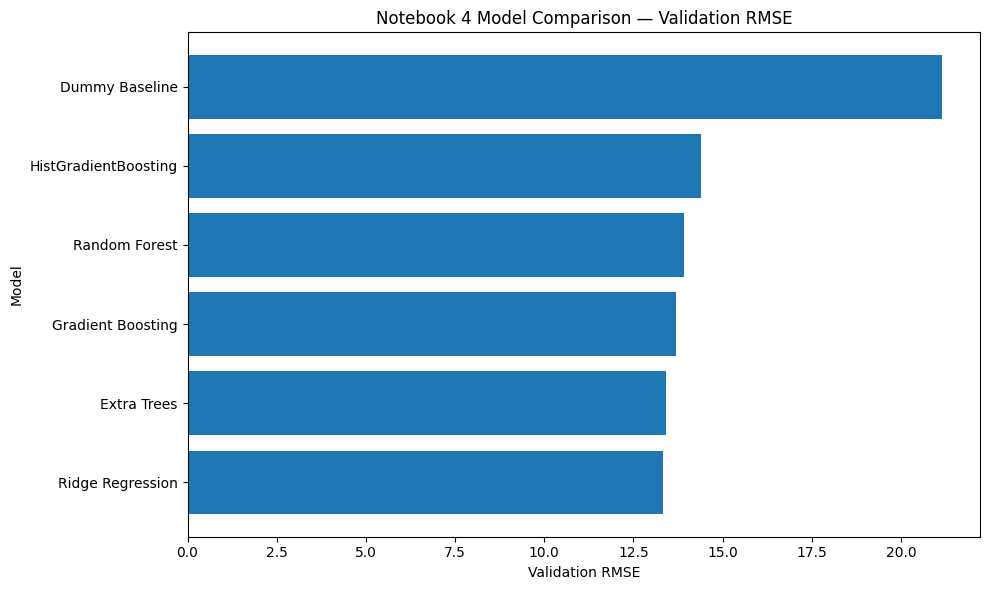

PASS: model_comparison_rmse.png (118.2 KB)


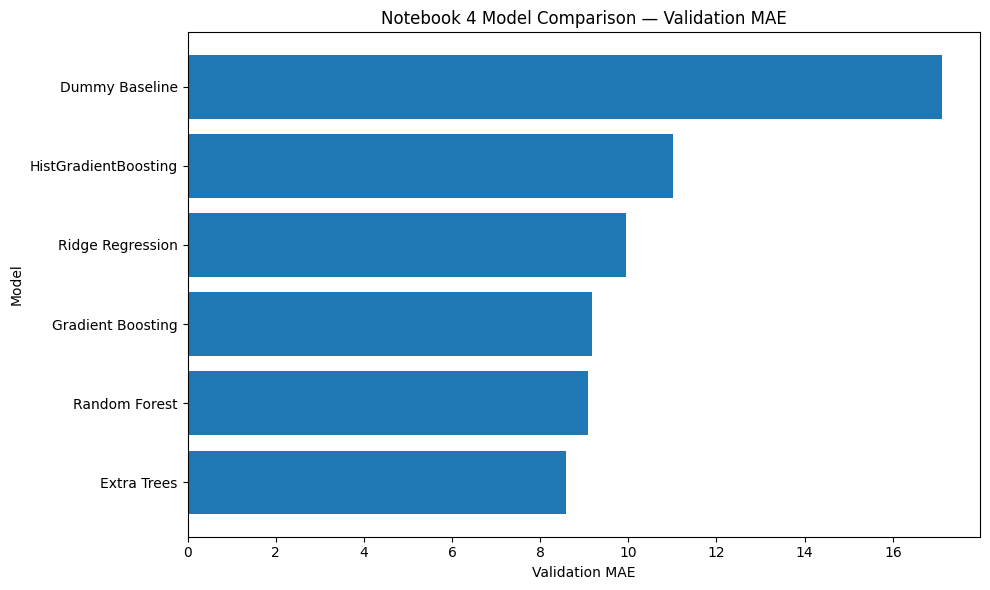

PASS: model_comparison_mae.png (112.8 KB)


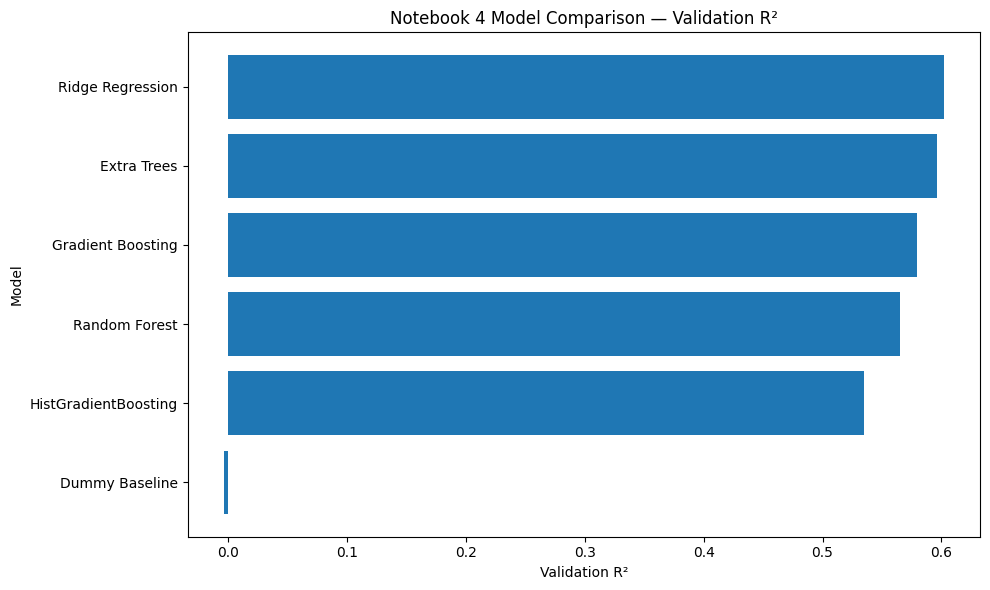

PASS: model_comparison_r2.png (110.3 KB)


In [13]:
# ============================================================
# 13. MODEL COMPARISON VISUALISATIONS
# ============================================================

generated_visualisations = []

def save_current_figure(filename):
    output_path = RESULTS_VIS_DIR / filename
    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()
    plt.close()

    if not output_path.exists() or output_path.stat().st_size == 0:
        raise RuntimeError(
            f"Visualisation was not saved correctly: {output_path}"
        )

    generated_visualisations.append(output_path)
    print(
        f"PASS: {output_path.name} "
        f"({output_path.stat().st_size / 1024:.1f} KB)"
    )


rmse_plot_df = model_comparison_final_df.sort_values(
    "RMSE",
    ascending=True,
)

plt.figure(figsize=(10, 6))
plt.barh(rmse_plot_df["model"], rmse_plot_df["RMSE"])
plt.xlabel("Validation RMSE")
plt.ylabel("Model")
plt.title("Notebook 4 Model Comparison — Validation RMSE")
plt.tight_layout()
save_current_figure("model_comparison_rmse.png")


mae_plot_df = model_comparison_final_df.sort_values(
    "MAE",
    ascending=True,
)

plt.figure(figsize=(10, 6))
plt.barh(mae_plot_df["model"], mae_plot_df["MAE"])
plt.xlabel("Validation MAE")
plt.ylabel("Model")
plt.title("Notebook 4 Model Comparison — Validation MAE")
plt.tight_layout()
save_current_figure("model_comparison_mae.png")


r2_plot_df = model_comparison_final_df.sort_values(
    "R2",
    ascending=True,
)

plt.figure(figsize=(10, 6))
plt.barh(r2_plot_df["model"], r2_plot_df["R2"])
plt.xlabel("Validation R²")
plt.ylabel("Model")
plt.title("Notebook 4 Model Comparison — Validation R²")
plt.tight_layout()
save_current_figure("model_comparison_r2.png")


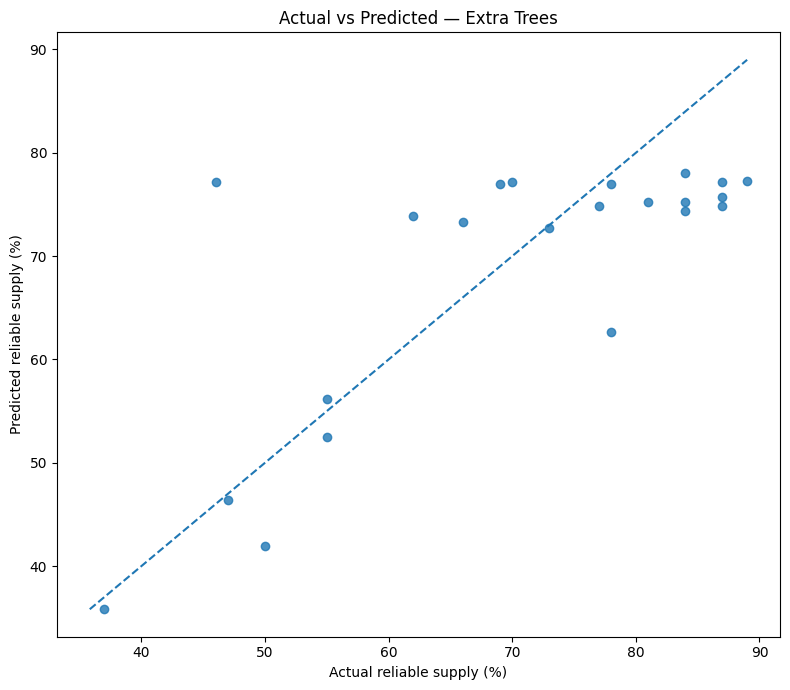

PASS: actual_vs_predicted.png (154.5 KB)


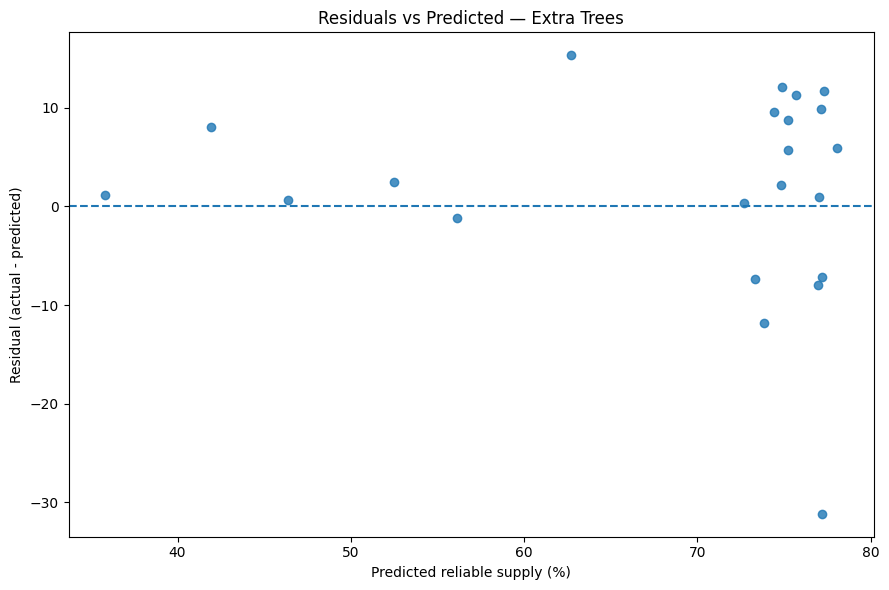

PASS: residuals_vs_predicted.png (114.6 KB)


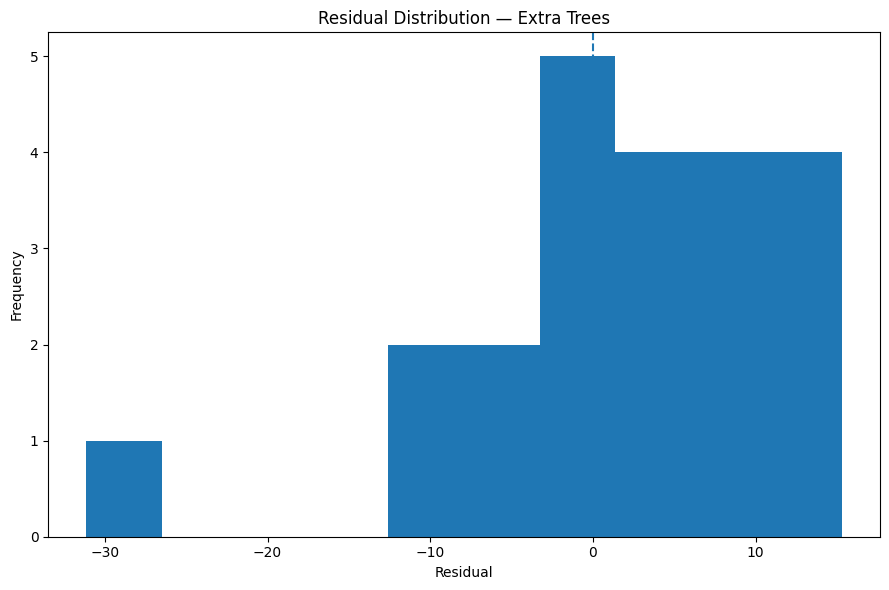

PASS: residual_distribution.png (60.4 KB)


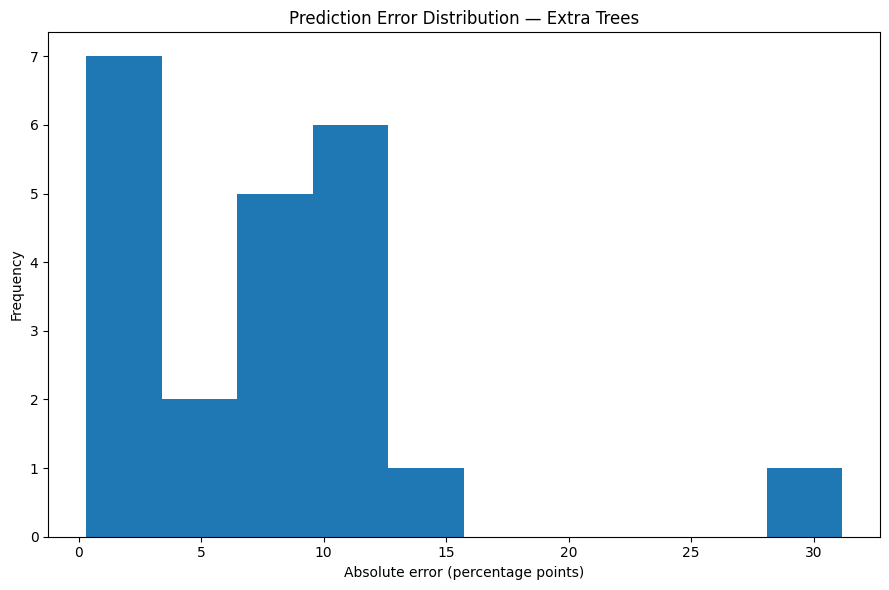

PASS: absolute_error_distribution.png (73.5 KB)


In [14]:
# ============================================================
# 13B. BEST-MODEL VISUALISATIONS
# ============================================================

# Actual vs predicted
plt.figure(figsize=(8, 7))
plt.scatter(
    analysis_predictions_df[ACTUAL_COLUMN],
    analysis_predictions_df[PREDICTED_COLUMN],
    alpha=0.8,
)

plot_min = float(min(
    analysis_predictions_df[ACTUAL_COLUMN].min(),
    analysis_predictions_df[PREDICTED_COLUMN].min(),
))
plot_max = float(max(
    analysis_predictions_df[ACTUAL_COLUMN].max(),
    analysis_predictions_df[PREDICTED_COLUMN].max(),
))

plt.plot([plot_min, plot_max], [plot_min, plot_max], linestyle="--")
plt.xlabel("Actual reliable supply (%)")
plt.ylabel("Predicted reliable supply (%)")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.tight_layout()
save_current_figure("actual_vs_predicted.png")


# Residuals vs predicted
plt.figure(figsize=(9, 6))
plt.scatter(
    analysis_predictions_df[PREDICTED_COLUMN],
    analysis_predictions_df["residual"],
    alpha=0.8,
)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted reliable supply (%)")
plt.ylabel("Residual (actual - predicted)")
plt.title(f"Residuals vs Predicted — {best_model_name}")
plt.tight_layout()
save_current_figure("residuals_vs_predicted.png")


# Residual distribution
plt.figure(figsize=(9, 6))
plt.hist(
    analysis_predictions_df["residual"],
    bins=min(10, max(5, len(analysis_predictions_df) // 2)),
)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title(f"Residual Distribution — {best_model_name}")
plt.tight_layout()
save_current_figure("residual_distribution.png")


# Absolute error distribution
plt.figure(figsize=(9, 6))
plt.hist(
    analysis_predictions_df[ERROR_COLUMN],
    bins=min(10, max(5, len(analysis_predictions_df) // 2)),
)
plt.xlabel("Absolute error (percentage points)")
plt.ylabel("Frequency")
plt.title(f"Prediction Error Distribution — {best_model_name}")
plt.tight_layout()
save_current_figure("absolute_error_distribution.png")


## 14. Feature importance

Notebook 4's raw-feature permutation importance is preferred because it is directly interpretable in the original predictor space.

If that file is missing or empty, Notebook 5 computes permutation importance from the saved final model and reconstructed final test predictors. This is an interpretation step only; it is not used to re-select the model.


Feature importance source: Notebook 4 permutation importance
Features ranked: 12


,feature,importance_mean,importance_std,importance
0,water_access_rate_pct,2.674281e+00,1.072935e+00,2.674281e+00
1,water_access_gap_pct,2.459256e+00,9.777579e-01,2.459256e+00
2,rural_population_share_pct,5.450940e-01,5.909520e-01,5.450940e-01
3,urban_population_share_pct,1.931551e-01,2.669898e-01,1.931551e-01
4,rural_population,1.296149e-01,1.324314e-01,1.296149e-01
5,rural_population_with_access_to_water,3.423769e-02,5.143867e-02,3.423769e-02
6,population,1.271347e-02,6.990098e-02,1.271347e-02
7,wsa_name,-2.753353e-15,8.837264e-16,-2.753353e-15
8,population_with_access_to_water,-1.861139e-02,3.209215e-02,-1.861139e-02
9,urban_population,-7.768006e-02,2.341815e-02,-7.768006e-02


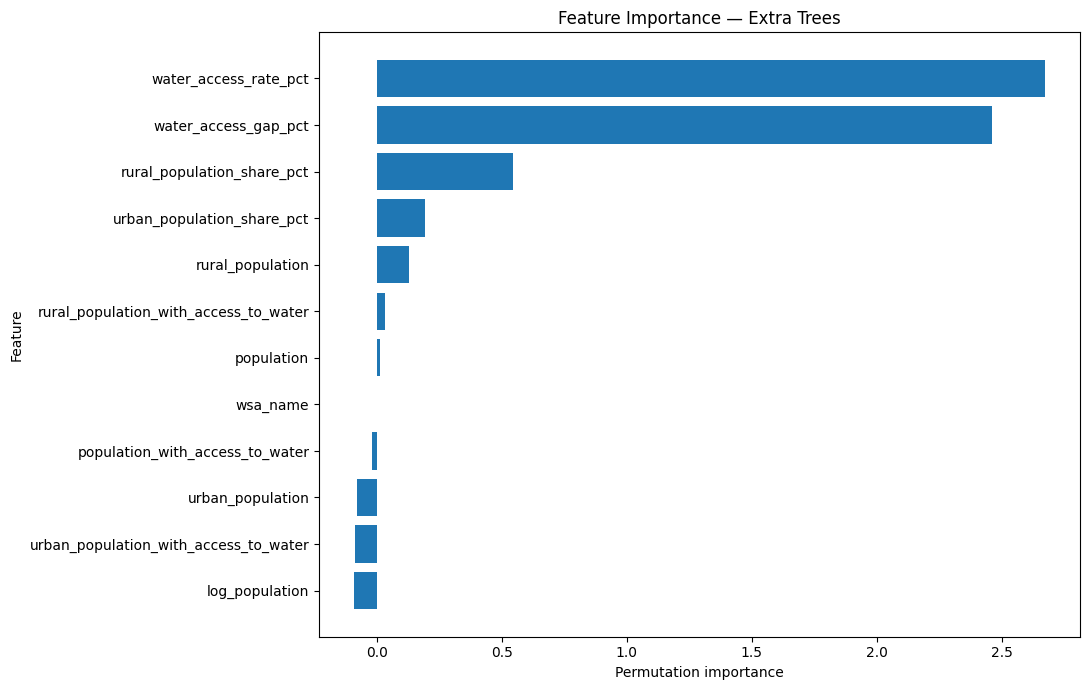

PASS: feature_importance.png (174.6 KB)


In [15]:
# ============================================================
# 14. FEATURE IMPORTANCE
# ============================================================

feature_importance_source = None

permutation_df = load_optional_csv(
    NB4_PATHS["permutation_importance"],
    required_columns=["feature", "importance_mean"],
    label="Notebook 4 permutation importance",
)

if permutation_df is not None:
    feature_importance_final_df = permutation_df.copy()
    feature_importance_final_df["importance"] = pd.to_numeric(
        feature_importance_final_df["importance_mean"],
        errors="raise",
    )
    feature_importance_source = "Notebook 4 permutation importance"

else:
    print(
        "Notebook 4 permutation-importance file unavailable. "
        "Computing permutation importance from the real saved model "
        "and final test set."
    )

    perm = permutation_importance(
        best_model,
        X_test_for_model,
        y_test_rebuilt,
        n_repeats=30,
        random_state=RANDOM_STATE,
        scoring="neg_root_mean_squared_error",
    )

    feature_importance_final_df = pd.DataFrame({
        "feature": X_test_for_model.columns,
        "importance": perm.importances_mean,
        "importance_std": perm.importances_std,
    })

    feature_importance_source = (
        "Recomputed permutation importance on final test data"
    )

if feature_importance_final_df.empty:
    raise RuntimeError("Feature-importance analysis produced zero rows.")

if feature_importance_final_df["feature"].isna().any():
    raise ValueError("Feature-importance table contains missing feature names.")

feature_importance_final_df["importance"] = pd.to_numeric(
    feature_importance_final_df["importance"],
    errors="raise",
)

if not np.isfinite(
    feature_importance_final_df["importance"].to_numpy()
).all():
    raise ValueError(
        "Feature-importance values contain NaN or infinity."
    )

feature_importance_final_df = (
    feature_importance_final_df
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

top_feature_count = min(15, len(feature_importance_final_df))
top_features_df = feature_importance_final_df.head(top_feature_count).copy()

STATUS["feature_importance_generated"] = True

print("Feature importance source:", feature_importance_source)
print("Features ranked:", len(feature_importance_final_df))
display(top_features_df)


plot_df = top_features_df.sort_values("importance", ascending=True)

plt.figure(figsize=(11, 7))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Permutation importance")
plt.ylabel("Feature")
plt.title(f"Feature Importance — {best_model_name}")
plt.tight_layout()
save_current_figure("feature_importance.png")


## 15. Outage-risk proxy and high-priority review

The risk proxy is the complement of predicted reliability:

`100 - predicted reliability`

It is a **relative decision-support indicator**, not a calibrated outage-event probability.


In [16]:
# ============================================================
# 15. OUTAGE-RISK PROXY ANALYSIS
# ============================================================

risk_analysis_df = analysis_predictions_df.copy()

expected_risk = 100.0 - risk_analysis_df[PREDICTED_COLUMN].to_numpy()

if not np.allclose(
    risk_analysis_df[RISK_PROXY_COLUMN].to_numpy(),
    expected_risk,
    rtol=0,
    atol=1e-10,
):
    raise RuntimeError(
        "Outage-risk proxy is inconsistent with "
        "100 - predicted reliability."
    )

risk_analysis_df = risk_analysis_df.sort_values(
    RISK_PROXY_COLUMN,
    ascending=False,
).reset_index(drop=True)

print(
    "Highest predicted outage-risk proxy values "
    "(decision-support ranking only):"
)

display(
    risk_analysis_df[
        [
            c for c in [
                GEO_KEY,
                PREDICTED_COLUMN,
                RISK_PROXY_COLUMN,
                ACTUAL_COLUMN,
                ERROR_COLUMN,
            ]
            if c in risk_analysis_df.columns
        ]
    ].head(10)
)


Highest predicted outage-risk proxy values (decision-support ranking only):


,wsa_name,predicted_reliable_supply_pct,predicted_outage_risk_proxy_pct,actual_reliable_supply_pct,absolute_error
0,Sekhukhune,35.824094,64.175906,37.0,1.175906
1,King Cetshwayo,41.925725,58.074275,50.0,8.074275
2,Uthukela,46.369666,53.630334,47.0,0.630334
3,Moses Kotane,52.490718,47.509282,55.0,2.509282
4,Umgungundlovu,56.130969,43.869031,55.0,1.130969
5,Newcastle,62.682394,37.317606,78.0,15.317606
6,City of uMhlathuze,72.705854,27.294146,73.0,0.294146
7,Richtersveld,73.334063,26.665937,66.0,7.334063
8,!Kheis,73.851218,26.148782,62.0,11.851218
9,Ubuntu,74.396804,25.603196,84.0,9.603196


## 16. Optional Gauteng municipality results

Notebook 4 also saved a Gauteng municipality prediction artefact when available. Notebook 5 treats it as supplementary evidence and never substitutes it for the untouched final-test evaluation.


In [17]:
# ============================================================
# 16. OPTIONAL GAUTENG RESULTS
# ============================================================

gauteng_path = PREDICTIONS_DIR / "gauteng_municipality_predictions.csv"

gauteng_predictions_df = load_optional_csv(
    gauteng_path,
    label="Notebook 4 Gauteng municipality predictions",
)

if gauteng_predictions_df is not None:
    print("Gauteng prediction rows:", len(gauteng_predictions_df))
    display(gauteng_predictions_df)
else:
    print(
        "Gauteng municipality prediction output is not available. "
        "This does not invalidate the final test evaluation."
    )


Gauteng prediction rows: 9


,wsa_name,predicted_reliable_supply_pct,predicted_outage_risk_proxy_pct
0,Midvaal,72.517738,27.482262
1,Rand West City,74.579190,25.420810
2,Mogale City,75.447005,24.552995
3,Merafong City,77.333304,22.666696
4,Emfuleni,77.554274,22.445726
5,Lesedi,77.712497,22.287503
6,City of Tshwane Metropolitan Municipality,78.159630,21.840370
7,City of Johannesburg Metropolitan Municipality,78.239774,21.760226
8,Ekurhuleni Metropolitan Municipality,78.552546,21.447454


## 17. Project findings and interpretation

The final interpretation is generated from the runtime results. It remains within Notebook 4's scientific scope: service-reliability prediction and an outage-risk proxy, not event-level outage forecasting.


In [18]:
# ============================================================
# 17. PROJECT FINDINGS AND INTERPRETATION
# ============================================================

top_feature_names = (
    feature_importance_final_df["feature"]
    .head(min(5, len(feature_importance_final_df)))
    .astype(str)
    .tolist()
)

worst_row = largest_errors_df.iloc[0]
worst_area = (
    str(worst_row[GEO_KEY])
    if GEO_KEY in largest_errors_df.columns
    else "the largest-error test observation"
)
worst_error = float(worst_row[ERROR_COLUMN])

if final_r2 >= 0.70:
    performance_assessment = "strong"
elif final_r2 >= 0.50:
    performance_assessment = "moderate"
elif final_r2 >= 0.30:
    performance_assessment = "limited-to-moderate"
else:
    performance_assessment = "limited"

project_findings = {
    "project": "ANLOK Water Prediction Project",
    "problem_type": "regression",
    "prediction_target": TARGET_COLUMN,
    "source_target_column": RAW_TARGET_COLUMN,
    "what_the_model_predicts": (
        "Municipal/service-area population reliable water-supply "
        "percentage."
    ),
    "what_the_model_does_not_predict": (
        "Verified future outage events, outage duration, or outage "
        "probability."
    ),
    "best_model": best_model_name,
    "test_observations": test_observations,
    "predictors": number_of_predictors,
    "final_test_metrics": calculated_metrics,
    "performance_assessment": performance_assessment,
    "top_features": top_feature_names,
    "largest_test_error": {
        "area": worst_area,
        "absolute_error_percentage_points": worst_error,
    },
    "risk_proxy_definition": (
        "100 - predicted_reliable_supply_pct"
    ),
    "decision_support_interpretation": (
        "The model can help prioritise areas for further investigation "
        "by estimating water-service reliability and a complementary "
        "risk proxy. It should not replace engineering inspection, "
        "operational monitoring, or verified outage records."
    ),
    "weather_in_primary_model": bool(
        final_config.get("weather_used_in_primary_model", False)
    ),
    "weather_exclusion_reason": final_config.get(
        "weather_reason",
        "Not documented in Notebook 4.",
    ),
}

print(json.dumps(project_findings, indent=2, default=str))


{
  "project": "ANLOK Water Prediction Project",
  "problem_type": "regression",
  "prediction_target": "target_reliable_supply_pct",
  "source_target_column": "population_reliable_supply_1",
  "what_the_model_predicts": "Municipal/service-area population reliable water-supply percentage.",
  "what_the_model_does_not_predict": "Verified future outage events, outage duration, or outage probability.",
  "best_model": "Extra Trees",
  "test_observations": 22,
  "predictors": 12,
  "final_test_metrics": {
    "MAE": 7.8563237995449136,
    "MSE": 106.45730041724823,
    "RMSE": 10.317814711325662,
    "R2": 0.553584011419614,
    "MAPE_pct": 11.756574668798379
  },
  "performance_assessment": "moderate",
  "top_features": [
    "water_access_rate_pct",
    "water_access_gap_pct",
    "rural_population_share_pct",
    "urban_population_share_pct",
    "rural_population"
  ],
  "largest_test_error": {
    "area": "Mohokare",
    "absolute_error_percentage_points": 31.163206616649703
  },
  "

## 18. Limitations

The limitations below follow directly from Notebook 4's methodology and the validated final results.


In [19]:
# ============================================================
# 18. LIMITATIONS
# ============================================================

limitations = [
    (
        "The project does not contain a verified historical event-level "
        "water-outage target. The model predicts water-service "
        "reliability instead."
    ),
    (
        "The outage-risk value is a complement of predicted reliability, "
        "not a calibrated probability of an outage."
    ),
    (
        f"The modelling dataset contains "
        f"{int(final_config.get('total_observations', len(X_full)))} "
        "municipal/service-area observations, which is small for broad "
        "operational deployment."
    ),
    (
        "The target is cross-sectional rather than an event-level time "
        "series, so the model cannot learn outage timing or duration."
    ),
    (
        "Daily weather was not joined to the primary reliability model "
        "because the project lacks a validated municipality-date key "
        "connecting those observations."
    ),
    (
        "Model predictions reflect associations present in the available "
        "data and should not be interpreted as causal effects."
    ),
    (
        "External validation on new municipalities and newer reporting "
        "periods is still required before operational use."
    ),
]

for idx, item in enumerate(limitations, 1):
    print(f"{idx}. {item}")


1. The project does not contain a verified historical event-level water-outage target. The model predicts water-service reliability instead.
2. The outage-risk value is a complement of predicted reliability, not a calibrated probability of an outage.
3. The modelling dataset contains 144 municipal/service-area observations, which is small for broad operational deployment.
4. The target is cross-sectional rather than an event-level time series, so the model cannot learn outage timing or duration.
5. Daily weather was not joined to the primary reliability model because the project lacks a validated municipality-date key connecting those observations.
6. Model predictions reflect associations present in the available data and should not be interpreted as causal effects.
7. External validation on new municipalities and newer reporting periods is still required before operational use.


## 19. Recommendations and scalability

### Technical recommendations
Future technical work should focus on:
- more observations and newer reporting periods;
- true historical outage/service-interruption records;
- aligned municipality/date identifiers;
- infrastructure condition and maintenance data;
- reservoir/treatment/pump operational data;
- demand/consumption observations;
- external geographic validation;
- repeated or nested cross-validation where dataset size permits;
- monitored deployment only after prospective validation.

### Problem-domain recommendations
Use the current model as a prioritisation and decision-support layer. High-risk-proxy areas should trigger deeper data review and engineering/operational investigation rather than automatic claims of an outage.


In [20]:
# ============================================================
# 19. RECOMMENDATION RECORDS
# ============================================================

technical_recommendations = [
    "Collect verified historical outage/service-interruption events.",
    "Add outage start/end timestamps, duration, cause and affected area.",
    "Create a consistent municipality-date key for safe weather joins.",
    "Add infrastructure condition, pump, treatment and reservoir data.",
    "Add aligned water-demand and consumption observations.",
    "Collect more municipalities and multiple reporting periods.",
    "Perform external validation on unseen regions and newer time periods.",
    "Monitor model drift and error if the model is later deployed.",
]

domain_recommendations = [
    (
        "Use predictions to prioritise areas for investigation, not as "
        "automatic outage declarations."
    ),
    (
        "Combine model outputs with engineering inspections and "
        "operational water-system data."
    ),
    (
        "Treat large residuals as signals for data-quality review or "
        "missing local explanatory variables."
    ),
]

print("Technical recommendations:")
for item in technical_recommendations:
    print("-", item)

print()
print("Problem-domain recommendations:")
for item in domain_recommendations:
    print("-", item)


Technical recommendations:
- Collect verified historical outage/service-interruption events.
- Add outage start/end timestamps, duration, cause and affected area.
- Create a consistent municipality-date key for safe weather joins.
- Add infrastructure condition, pump, treatment and reservoir data.
- Add aligned water-demand and consumption observations.
- Collect more municipalities and multiple reporting periods.
- Perform external validation on unseen regions and newer time periods.
- Monitor model drift and error if the model is later deployed.

Problem-domain recommendations:
- Use predictions to prioritise areas for investigation, not as automatic outage declarations.
- Combine model outputs with engineering inspections and operational water-system data.
- Treat large residuals as signals for data-quality review or missing local explanatory variables.


## 20. Save machine-readable Notebook 5 outputs

Every important CSV is reopened after saving and must contain rows. JSON files are reloaded after saving and must contain non-empty objects.


In [21]:
# ============================================================
# 20. SAVE AND VERIFY NOTEBOOK 5 OUTPUTS
# ============================================================

def save_nonempty_csv(df, path, label=None):
    path = Path(path)
    label = label or path.name

    if df is None:
        raise ValueError(f"{label}: dataframe is None.")

    if df.empty:
        raise ValueError(
            f"{label}: refusing to save an empty dataframe."
        )

    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)

    if not path.exists() or path.stat().st_size == 0:
        raise RuntimeError(f"{label}: file was not saved correctly.")

    saved_check = pd.read_csv(path)

    if saved_check.empty:
        raise RuntimeError(
            f"Saved output is unexpectedly empty: {path}"
        )

    print(
        f"PASS: {label} — {len(saved_check):,} rows saved to "
        f"{path.relative_to(PROJECT_ROOT)}"
    )
    return path


def save_verified_json(data, path, label=None):
    path = Path(path)
    label = label or path.name

    if not isinstance(data, dict) or not data:
        raise ValueError(
            f"{label}: refusing to save an empty JSON object."
        )

    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as handle:
        json.dump(data, handle, indent=2, default=str)

    if not path.exists() or path.stat().st_size == 0:
        raise RuntimeError(f"{label}: JSON file was not saved correctly.")

    with open(path, "r", encoding="utf-8") as handle:
        check = json.load(handle)

    if not isinstance(check, dict) or not check:
        raise RuntimeError(f"{label}: saved JSON validation failed.")

    print(
        f"PASS: {label} saved to "
        f"{path.relative_to(PROJECT_ROOT)}"
    )
    return path


# 1. All-model validation comparison.
save_nonempty_csv(
    model_comparison_final_df,
    RESULTS_DIR / "model_comparison.csv",
    "Final model comparison",
)

# 2. Best-model final test summary.
save_nonempty_csv(
    best_model_summary_df,
    RESULTS_DIR / "best_model_summary.csv",
    "Best-model summary",
)

# 3. Validated final predictions.
save_nonempty_csv(
    analysis_predictions_df,
    RESULTS_DIR / "best_model_predictions.csv",
    "Best-model predictions",
)

# 4. Largest errors.
save_nonempty_csv(
    largest_errors_df,
    RESULTS_DIR / "largest_prediction_errors.csv",
    "Largest prediction errors",
)

# 5. Feature importance.
save_nonempty_csv(
    feature_importance_final_df,
    RESULTS_DIR / "feature_importance.csv",
    "Feature importance",
)

# 6. Optional Gauteng output.
if gauteng_predictions_df is not None:
    save_nonempty_csv(
        gauteng_predictions_df,
        RESULTS_DIR / "gauteng_municipality_predictions.csv",
        "Gauteng municipality predictions",
    )

final_metrics_json = {
    "project": "ANLOK Water Prediction Project",
    "problem_type": "regression",
    "best_model": best_model_name,
    "test_samples": test_observations,
    "metrics": calculated_metrics,
    "metric_interpretation": {
        "MAE": (
            "Average absolute error in reliable-supply percentage points."
        ),
        "RMSE": (
            "Root mean squared error; gives larger errors more weight."
        ),
        "R2": (
            "Held-out variance explained relative to a mean baseline."
        ),
        "MAPE_pct": (
            "Mean absolute percentage error; reported only when actual "
            "targets are non-zero."
        ),
    },
}

save_verified_json(
    final_metrics_json,
    RESULTS_DIR / "final_metrics.json",
    "Final metrics",
)

final_model_metadata = {
    "project": "ANLOK Water Prediction Project",
    "notebook": "Notebook 5 — Final Analysis",
    "source_notebook": "NB4_Production.ipynb",
    "final_model": best_model_name,
    "model_file": str(
        NB4_PATHS["best_model"].relative_to(PROJECT_ROOT)
    ),
    "problem_type": "regression",
    "source_target_column": RAW_TARGET_COLUMN,
    "model_target": TARGET_COLUMN,
    "true_event_level_outage_target_available": bool(
        final_config.get("true_outage_target_available", False)
    ),
    "outage_risk_proxy": (
        "100 - predicted_reliable_supply_pct"
    ),
    "test_samples": test_observations,
    "features": list(X_test_for_model.columns),
    "number_of_predictors": number_of_predictors,
    "metrics": calculated_metrics,
    "feature_importance_source": feature_importance_source,
    "saved_notebook4_predictions_matched_recomputation": bool(
        saved_predictions_match
    ),
    "generated_utc": datetime.now(timezone.utc).isoformat(),
}

save_verified_json(
    final_model_metadata,
    RESULTS_DIR / "final_model_metadata.json",
    "Final model metadata",
)

save_verified_json(
    project_findings,
    RESULTS_DIR / "project_findings.json",
    "Project findings",
)

STATUS["final_predictions_saved"] = True
STATUS["results_saved"] = True


PASS: Final model comparison — 6 rows saved to Outputs/Results/model_comparison.csv
PASS: Best-model summary — 1 rows saved to Outputs/Results/best_model_summary.csv
PASS: Best-model predictions — 22 rows saved to Outputs/Results/best_model_predictions.csv
PASS: Largest prediction errors — 10 rows saved to Outputs/Results/largest_prediction_errors.csv
PASS: Feature importance — 12 rows saved to Outputs/Results/feature_importance.csv
PASS: Gauteng municipality predictions — 9 rows saved to Outputs/Results/gauteng_municipality_predictions.csv
PASS: Final metrics saved to Outputs/Results/final_metrics.json
PASS: Final model metadata saved to Outputs/Results/final_model_metadata.json
PASS: Project findings saved to Outputs/Results/project_findings.json


## 21. Generate final project summary

The Markdown report below is populated dynamically from the actual validated results produced in this run.


In [22]:
# ============================================================
# 21. FINAL PROJECT SUMMARY MARKDOWN
# ============================================================

metric_lines = [
    f"- MAE: {final_mae:.4f}",
    f"- MSE: {final_mse:.4f}",
    f"- RMSE: {final_rmse:.4f}",
    f"- R²: {final_r2:.4f}",
]

if final_mape is not None:
    metric_lines.append(f"- MAPE: {final_mape:.2f}%")

feature_lines = [
    f"- {name}"
    for name in top_feature_names
]

model_lines = [
    f"- {name}"
    for name in model_comparison_final_df["model"].astype(str).tolist()
]

limitation_lines = [
    f"- {item}"
    for item in limitations
]

technical_lines = [
    f"- {item}"
    for item in technical_recommendations
]

domain_lines = [
    f"- {item}"
    for item in domain_recommendations
]

summary_lines = [
    "# ANLOK WATER PREDICTION PROJECT",
    "",
    "## Problem",
    (
        "The project investigates water-service reliability in South "
        "African municipal/service areas using publicly available data "
        "and machine-learning methods."
    ),
    "",
    "## Dataset",
    (
        f"Notebook 4's final modelling table contains {len(X_full)} "
        f"observations and {number_of_predictors} predictors."
    ),
    "",
    "## Methodology",
    (
        "Notebook 4 used a train/validation/final-test design. Models were "
        "selected on validation performance and the selected final model "
        "was evaluated once on the held-out test set."
    ),
    "",
    "## Data Preparation",
    (
        "Notebook 5 reuses the exact Notebook 4 modelling table and the "
        "saved fitted model pipeline. It does not repeat data cleaning or "
        "silently drop rows."
    ),
    "",
    "## Feature Engineering",
    (
        "The final predictor set includes population, water-access, "
        "urban/rural composition and the municipality/service-area "
        "identifier used by Notebook 4."
    ),
    "",
    "## Models Evaluated",
    *model_lines,
    "",
    "## Final Model",
    best_model_name,
    "",
    "## Evaluation Results",
    *metric_lines,
    f"- Final test observations: {test_observations}",
    "",
    "## Important Features",
    *feature_lines,
    "",
    "## Key Findings",
    (
        f"The selected {best_model_name} model achieved "
        f"{performance_assessment} held-out explanatory performance. "
        f"Its average absolute error was {final_mae:.2f} reliability "
        "percentage points."
    ),
    (
        "The most influential predictors indicate that measured water "
        "access and urban/rural population structure carry important "
        "predictive information for the reliability target."
    ),
    "",
    "## Error Analysis",
    (
        f"The largest absolute error in the held-out test set was "
        f"{worst_error:.2f} percentage points for {worst_area}. "
        f"The mean residual was {mean_residual:.2f} percentage points."
    ),
    "",
    "## Limitations",
    *limitation_lines,
    "",
    "## Scalability",
    (
        "The current pipeline is reproducible and can support additional "
        "municipal observations, but operational scaling requires more "
        "historical data, aligned temporal keys, infrastructure data, "
        "external validation and model monitoring."
    ),
    "",
    "## Recommendations",
    "### Technical recommendations",
    *technical_lines,
    "",
    "### Problem-domain recommendations",
    *domain_lines,
    "",
    "## Conclusion",
    (
        "The ANLOK project demonstrates an end-to-end data-science "
        "workflow from public water data through cleaning, exploratory "
        "analysis, feature engineering, machine-learning modelling, "
        "validation and final interpretation. The final model predicts "
        "water-service reliability and can support prioritisation of "
        "areas for further investigation. It must not be presented as a "
        "verified outage-event forecasting system."
    ),
]

final_project_summary_text = "\n".join(summary_lines).strip() + "\n"

summary_path = RESULTS_DIR / "final_project_summary.md"
summary_path.write_text(
    final_project_summary_text,
    encoding="utf-8",
)

if not summary_path.exists() or summary_path.stat().st_size == 0:
    raise RuntimeError("Final project summary was not saved correctly.")

if len(summary_path.read_text(encoding="utf-8").strip()) < 200:
    raise RuntimeError("Final project summary is unexpectedly short.")

STATUS["project_summary_generated"] = True

print(final_project_summary_text)
print(
    "PASS: Final project summary saved to",
    summary_path.relative_to(PROJECT_ROOT),
)


# ANLOK WATER PREDICTION PROJECT

## Problem
The project investigates water-service reliability in South African municipal/service areas using publicly available data and machine-learning methods.

## Dataset
Notebook 4's final modelling table contains 144 observations and 12 predictors.

## Methodology
Notebook 4 used a train/validation/final-test design. Models were selected on validation performance and the selected final model was evaluated once on the held-out test set.

## Data Preparation
Notebook 5 reuses the exact Notebook 4 modelling table and the saved fitted model pipeline. It does not repeat data cleaning or silently drop rows.

## Feature Engineering
The final predictor set includes population, water-access, urban/rural composition and the municipality/service-area identifier used by Notebook 4.

## Models Evaluated
- Ridge Regression
- Extra Trees
- Gradient Boosting
- Random Forest
- HistGradientBoosting
- Dummy Baseline

## Final Model
Extra Trees

## Evaluation Result

## 22. Final output audit

Notebook 5 now recursively audits its own output directory.

Status meanings:
- **PASS** — usable non-empty output;
- **WARNING** — readable file that needs review;
- **EMPTY** — zero bytes or zero-row CSV;
- **MISSING** — expected output not found.

The notebook raises an error if any expected critical Notebook 5 output is not `PASS`.


In [23]:
# ============================================================
# 22. FINAL OUTPUT AUDIT
# ============================================================

expected_result_files = [
    RESULTS_DIR / "model_comparison.csv",
    RESULTS_DIR / "best_model_summary.csv",
    RESULTS_DIR / "best_model_predictions.csv",
    RESULTS_DIR / "largest_prediction_errors.csv",
    RESULTS_DIR / "final_metrics.json",
    RESULTS_DIR / "project_findings.json",
    RESULTS_DIR / "feature_importance.csv",
    RESULTS_DIR / "final_model_metadata.json",
    RESULTS_DIR / "final_project_summary.md",
    RESULTS_VIS_DIR / "model_comparison_rmse.png",
    RESULTS_VIS_DIR / "model_comparison_mae.png",
    RESULTS_VIS_DIR / "model_comparison_r2.png",
    RESULTS_VIS_DIR / "actual_vs_predicted.png",
    RESULTS_VIS_DIR / "residuals_vs_predicted.png",
    RESULTS_VIS_DIR / "residual_distribution.png",
    RESULTS_VIS_DIR / "absolute_error_distribution.png",
    RESULTS_VIS_DIR / "feature_importance.png",
]


def audit_output_file(path):
    path = Path(path)

    record = {
        "File": str(path.relative_to(RESULTS_DIR))
        if RESULTS_DIR in path.parents or path == RESULTS_DIR
        else str(path),
        "Type": path.suffix.lower().lstrip(".").upper() or "FILE",
        "Size": "-",
        "Rows": "-",
        "Status": "MISSING",
    }

    if not path.exists():
        return record

    size = path.stat().st_size
    record["Size"] = f"{size / 1024:.1f} KB"

    if size == 0:
        record["Status"] = "EMPTY"
        if path.suffix.lower() == ".csv":
            record["Rows"] = 0
        return record

    suffix = path.suffix.lower()

    if suffix == ".csv":
        try:
            df = pd.read_csv(path)
        except Exception as exc:
            record["Status"] = f"WARNING: {exc}"
            return record

        record["Rows"] = len(df)
        record["Status"] = "PASS" if len(df) > 0 else "EMPTY"

    elif suffix == ".json":
        try:
            with open(path, "r", encoding="utf-8") as handle:
                obj = json.load(handle)
            record["Status"] = (
                "PASS"
                if isinstance(obj, dict) and len(obj) > 0
                else "EMPTY"
            )
        except Exception as exc:
            record["Status"] = f"WARNING: {exc}"

    elif suffix in {".png", ".jpg", ".jpeg"}:
        record["Status"] = "PASS" if size > 0 else "EMPTY"

    elif suffix == ".md":
        text = path.read_text(encoding="utf-8").strip()
        record["Status"] = "PASS" if text else "EMPTY"

    else:
        record["Status"] = "PASS"

    return record


audit_records = [
    audit_output_file(path)
    for path in sorted(
        [p for p in RESULTS_DIR.rglob("*") if p.is_file()]
    )
]

output_audit_df = pd.DataFrame(audit_records)

if output_audit_df.empty:
    raise RuntimeError("Notebook 5 output audit found no generated files.")

audit_csv_path = RESULTS_DIR / "output_audit.csv"

# Save once, then rebuild so the audit includes itself.
output_audit_df.to_csv(audit_csv_path, index=False)

audit_records = [
    audit_output_file(path)
    for path in sorted(
        [p for p in RESULTS_DIR.rglob("*") if p.is_file()]
    )
]
output_audit_df = pd.DataFrame(audit_records)
output_audit_df.to_csv(audit_csv_path, index=False)

display(output_audit_df)

expected_audit = pd.DataFrame([
    audit_output_file(path)
    for path in expected_result_files
])

critical_output_failures = expected_audit[
    expected_audit["Status"] != "PASS"
]

if not critical_output_failures.empty:
    display(critical_output_failures)
    raise RuntimeError(
        "Notebook 5 has missing or empty expected outputs. "
        "Success will not be reported."
    )

empty_expected_outputs = int(
    (expected_audit["Status"] == "EMPTY").sum()
)

if empty_expected_outputs != 0:
    raise RuntimeError(
        "One or more expected Notebook 5 outputs are empty."
    )

STATUS["visualisations_saved"] = (
    len(generated_visualisations) >= 8
)

if not STATUS["visualisations_saved"]:
    raise RuntimeError(
        "Expected final visualisations were not all generated."
    )

print("=" * 80)
print("FINAL OUTPUT AUDIT PASSED")
print("=" * 80)
print("Expected outputs:", len(expected_result_files))
print("Empty expected outputs:", empty_expected_outputs)
print("Files currently in Outputs/Results:", len(output_audit_df))


,File,Type,Size,Rows,Status
0,Visualisations/absolute_error_distribution.png,PNG,73.5 KB,-,PASS
1,Visualisations/actual_vs_predicted.png,PNG,154.5 KB,-,PASS
2,Visualisations/feature_importance.png,PNG,174.6 KB,-,PASS
3,Visualisations/model_comparison_mae.png,PNG,112.8 KB,-,PASS
4,Visualisations/model_comparison_r2.png,PNG,110.3 KB,-,PASS
5,Visualisations/model_comparison_rmse.png,PNG,118.2 KB,-,PASS
6,Visualisations/residual_distribution.png,PNG,60.4 KB,-,PASS
7,Visualisations/residuals_vs_predicted.png,PNG,114.6 KB,-,PASS
8,best_model_predictions.csv,CSV,5.9 KB,22,PASS
9,best_model_summary.csv,CSV,0.3 KB,1,PASS


FINAL OUTPUT AUDIT PASSED
Expected outputs: 17
Empty expected outputs: 0
Files currently in Outputs/Results: 19


## 23. Security check before Git staging

The notebook scans Notebook 5's generated text outputs for common GitHub token patterns and resets the remote URL to the credential-free HTTPS URL before staging.

The GitHub Personal Access Token is requested only when the push command is executed.


In [24]:
# ============================================================
# 23. SECURITY CHECK BEFORE GIT
# ============================================================

# Keep origin credential-free.
run_git(
    ["remote", "set-url", "origin", GITHUB_REPO_URL],
    check=True,
)

remote_after_reset = run_git(
    ["remote", "get-url", "origin"],
    check=True,
).stdout.strip()

if remote_after_reset != GITHUB_REPO_URL:
    raise RuntimeError("Origin remote contains an unexpected URL.")

token_patterns = [
    re.compile(r"\bghp_[A-Za-z0-9]{20,}\b"),
    re.compile(r"\bgithub_pat_[A-Za-z0-9_]{20,}\b"),
    re.compile(r"\bgho_[A-Za-z0-9]{20,}\b"),
    re.compile(r"\bghu_[A-Za-z0-9]{20,}\b"),
    re.compile(r"\bghs_[A-Za-z0-9]{20,}\b"),
    re.compile(r"\bghr_[A-Za-z0-9]{20,}\b"),
]

text_extensions = {
    ".csv", ".json", ".md", ".txt", ".py", ".ipynb",
}

security_hits = []

for path in RESULTS_DIR.rglob("*"):
    if not path.is_file():
        continue

    if path.suffix.lower() not in text_extensions:
        continue

    # Generated result files are small; cap defensive read size.
    if path.stat().st_size > 10 * 1024 * 1024:
        continue

    text = path.read_text(
        encoding="utf-8",
        errors="ignore",
    )

    for pattern in token_patterns:
        if pattern.search(text):
            security_hits.append(str(path.relative_to(PROJECT_ROOT)))
            break

if security_hits:
    raise RuntimeError(
        "Potential GitHub credential pattern found in generated files:\n"
        + "\n".join(f"- {item}" for item in security_hits)
    )

print("PASS: No GitHub token patterns found in Notebook 5 outputs.")
print("PASS: Git origin is credential-free.")


PASS: No GitHub token patterns found in Notebook 5 outputs.
PASS: Git origin is credential-free.


## 24. Locate the Notebook 5 file for Git staging

Colab does not always expose the currently open notebook as a filesystem file. This cell safely checks common locations. It never fabricates an `.ipynb`.

If the notebook is already in the repository or uploaded into `/content`, it is staged automatically. The project outputs can still be committed if the runtime does not expose the notebook file.


In [25]:
# ============================================================
# 24. LOCATE NOTEBOOK 5 FILE
# ============================================================

repo_notebook_path = PROJECT_ROOT / NOTEBOOK5_FILENAME
notebook_source_candidates = [
    repo_notebook_path,
    Path("/content") / NOTEBOOK5_FILENAME,
]

# Add exact-name matches under /content without recursively walking
# the cloned repository a second time.
notebook_source_candidates.extend(
    sorted(
        p for p in Path("/content").glob("*.ipynb")
        if p.name == NOTEBOOK5_FILENAME
    )
)

found_notebook_source = None

for candidate in notebook_source_candidates:
    if candidate.exists() and candidate.is_file():
        if candidate.stat().st_size > 0:
            found_notebook_source = candidate
            break

if found_notebook_source is not None:
    if found_notebook_source.resolve() != repo_notebook_path.resolve():
        repo_notebook_path.write_bytes(
            found_notebook_source.read_bytes()
        )

    # Validate copied notebook as JSON before staging.
    with open(repo_notebook_path, "r", encoding="utf-8") as handle:
        notebook_json_check = json.load(handle)

    if (
        not isinstance(notebook_json_check, dict)
        or "cells" not in notebook_json_check
        or not notebook_json_check["cells"]
    ):
        raise RuntimeError(
            "Located Notebook 5 file is not a valid non-empty notebook."
        )

    print(
        "PASS: Notebook 5 file available for Git staging:",
        repo_notebook_path.relative_to(PROJECT_ROOT),
    )
else:
    print(
        "WARNING: The active Colab notebook is not exposed as a local "
        "filesystem .ipynb, so the notebook file itself cannot be copied "
        "automatically in this runtime. Outputs/Results will still be "
        "staged. To include the notebook in the same commit, place "
        f"{NOTEBOOK5_FILENAME} in the repository root before running "
        "the Git cell."
    )


## 25. Git status, explicit staging, commit and secure push

Only Notebook 5 outputs and the Notebook 5 file (when available) are staged.

The token:
- is requested with `getpass`;
- is never printed;
- is never written to the remote URL;
- is passed to Git only through a temporary HTTP authorization header;
- is cleared from Python variables after the push command.


In [26]:
# ============================================================
# 25. GIT STATUS, COMMIT AND SECURE PUSH
# ============================================================

print("=" * 80)
print("GITHUB COMMIT AND PUSH")
print("=" * 80)

# Configure repository-local commit identity.
run_git(
    ["config", "user.name", "LulutheBA"],
    check=True,
)
run_git(
    ["config", "user.email", "lulutheba@users.noreply.github.com"],
    check=True,
)

# Reset origin again before any staging/push.
run_git(
    ["remote", "set-url", "origin", GITHUB_REPO_URL],
    check=True,
)

print()
print("Git status before staging:")
status_before = run_git(["status", "--short"], check=True)
print(
    status_before.stdout
    if status_before.stdout.strip()
    else "No uncommitted changes."
)

# Stage only Notebook 5 outputs.
run_git(
    ["add", "-A", "Outputs/Results"],
    check=True,
)

# Stage the notebook only if it is actually present.
if repo_notebook_path.exists():
    run_git(
        ["add", "--", NOTEBOOK5_FILENAME],
        check=True,
    )

staged_files_result = run_git(
    ["diff", "--cached", "--name-only"],
    check=True,
)

staged_files = [
    line.strip()
    for line in staged_files_result.stdout.splitlines()
    if line.strip()
]

print()
print("Staged files:")
if staged_files:
    for item in staged_files:
        print("  -", item)
else:
    print("  No new staged changes.")

# Final pre-commit token scan on staged text files.
for relative_name in staged_files:
    staged_path = PROJECT_ROOT / relative_name

    if (
        staged_path.exists()
        and staged_path.is_file()
        and staged_path.suffix.lower() in text_extensions
        and staged_path.stat().st_size <= 10 * 1024 * 1024
    ):
        text = staged_path.read_text(
            encoding="utf-8",
            errors="ignore",
        )
        for pattern in token_patterns:
            if pattern.search(text):
                raise RuntimeError(
                    "Refusing to commit a file that appears to contain "
                    f"a GitHub token: {relative_name}"
                )

commit_message = (
    "Add Notebook 5 final model analysis and project results"
)

commit_hash = None
commit_created_now = False

if staged_files:
    commit_result = run_git(
        ["commit", "-m", commit_message]
    )

    if commit_result.returncode != 0:
        combined = (
            commit_result.stdout + "\n" + commit_result.stderr
        ).lower()

        if "nothing to commit" not in combined:
            raise RuntimeError(
                "Git commit failed.\n"
                + (commit_result.stderr.strip()
                   or commit_result.stdout.strip())
            )
    else:
        commit_created_now = True

    commit_hash = run_git(
        ["rev-parse", "HEAD"],
        check=True,
    ).stdout.strip()

else:
    # Nothing new is not an error. Existing outputs may already be committed.
    commit_hash = run_git(
        ["rev-parse", "HEAD"],
        check=True,
    ).stdout.strip()
    print("Nothing new to commit.")

STATUS["git_commit_complete"] = True

# Ask for the token only when authentication is needed for push.
github_token = getpass(
    "Enter your GitHub Personal Access Token "
    "(input hidden; not saved): "
).strip()

if not github_token:
    raise ValueError("A GitHub token is required to push.")

github_username = "LulutheBA"

auth_string = f"{github_username}:{github_token}"
encoded_auth = base64.b64encode(
    auth_string.encode("utf-8")
).decode("ascii")

push_result = subprocess.run(
    [
        "git",
        "-c",
        "http.extraHeader=AUTHORIZATION: basic " + encoded_auth,
        "push",
        "origin",
        "HEAD:main",
    ],
    cwd=str(PROJECT_ROOT),
    capture_output=True,
    text=True,
    env=os.environ.copy(),
)

# Remove sensitive values from Python references immediately.
auth_string = None
encoded_auth = None
github_token = None

# Restore/confirm safe remote after push.
run_git(
    ["remote", "set-url", "origin", GITHUB_REPO_URL],
    check=True,
)

if push_result.returncode != 0:
    raise RuntimeError(
        "GitHub push failed. The token was not stored.\n"
        + (push_result.stderr.strip() or push_result.stdout.strip())
    )

STATUS["github_push_complete"] = True

print()
print("GitHub push output:")
print(
    push_result.stdout.strip()
    or push_result.stderr.strip()
    or "Push completed."
)

print()
print("=" * 80)
print("GITHUB PUSH COMPLETE")
print("=" * 80)
print("Repository:", REPO_NAME)
print("Branch: main")
print("Commit:", commit_hash)
print("Commit created in this run:", commit_created_now)
print("Message:", commit_message)
print("Status: SUCCESS")
print("Files staged in this run:")
for item in staged_files:
    print("  -", item)


GITHUB COMMIT AND PUSH

Git status before staging:
?? Outputs/Results/


Staged files:
  - Outputs/Results/Visualisations/absolute_error_distribution.png
  - Outputs/Results/Visualisations/actual_vs_predicted.png
  - Outputs/Results/Visualisations/feature_importance.png
  - Outputs/Results/Visualisations/model_comparison_mae.png
  - Outputs/Results/Visualisations/model_comparison_r2.png
  - Outputs/Results/Visualisations/model_comparison_rmse.png
  - Outputs/Results/Visualisations/residual_distribution.png
  - Outputs/Results/Visualisations/residuals_vs_predicted.png
  - Outputs/Results/best_model_predictions.csv
  - Outputs/Results/best_model_summary.csv
  - Outputs/Results/feature_importance.csv
  - Outputs/Results/final_metrics.json
  - Outputs/Results/final_model_metadata.json
  - Outputs/Results/final_project_summary.md
  - Outputs/Results/gauteng_municipality_predictions.csv
  - Outputs/Results/largest_prediction_errors.csv
  - Outputs/Results/model_comparison.csv
  - Outputs/Res

## 26. Verify repository state

The final Git check confirms the branch, commit hash, safe remote URL, and working-tree status after the push.


In [27]:
# ============================================================
# 26. VERIFY PUSH AND REPOSITORY STATE
# ============================================================

final_branch = run_git(
    ["branch", "--show-current"],
    check=True,
).stdout.strip()

final_commit = run_git(
    ["rev-parse", "HEAD"],
    check=True,
).stdout.strip()

final_remote = run_git(
    ["remote", "get-url", "origin"],
    check=True,
).stdout.strip()

final_status = run_git(
    ["status", "--short"],
    check=True,
).stdout.strip()

if final_remote != GITHUB_REPO_URL:
    raise RuntimeError(
        "Git remote is not the expected credential-free URL."
    )

print("Branch:", final_branch)
print("Commit:", final_commit)
print("Origin:", final_remote)
print(
    "Working tree:",
    final_status if final_status else "clean"
)

if final_status:
    print(
        "WARNING: Some local changes remain after the Notebook 5 push. "
        "Review them before making unrelated commits."
    )


Branch: main
Commit: c2cc7dff62180a49fb1cf43b01a1d164f73c25c3
Origin: https://github.com/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-.git
Working tree: clean


## 27. Final project completion check

A check is marked complete only when the corresponding execution state is true.


In [28]:
# ============================================================
# 27. FINAL PROJECT COMPLETION CHECK
# ============================================================

checklist = [
    ("Repository connected", STATUS["repository_connected"]),
    ("Previous notebook outputs detected", STATUS["nb4_outputs_detected"]),
    ("Final model loaded", STATUS["final_model_loaded"]),
    ("Test dataset loaded", STATUS["test_dataset_loaded"]),
    ("Model evaluated", STATUS["model_evaluated"]),
    ("Model comparison completed", STATUS["model_comparison_completed"]),
    ("Error analysis completed", STATUS["error_analysis_completed"]),
    ("Feature importance generated", STATUS["feature_importance_generated"]),
    ("Final predictions saved", STATUS["final_predictions_saved"]),
    ("Visualisations saved", STATUS["visualisations_saved"]),
    ("Results saved", STATUS["results_saved"]),
    ("Project summary generated", STATUS["project_summary_generated"]),
    ("Git commit step completed", STATUS["git_commit_complete"]),
    ("GitHub push completed", STATUS["github_push_complete"]),
]

print("=" * 80)
print("NOTEBOOK 5 PROJECT COMPLETION CHECK")
print("=" * 80)

for label, success in checklist:
    symbol = "✓" if success else "✗"
    print(f"[{symbol}] {label}")

failed_checks = [
    label
    for label, success in checklist
    if not success
]

if failed_checks:
    raise RuntimeError(
        "Notebook 5 cannot report success because these checks failed:\n"
        + "\n".join(f"- {item}" for item in failed_checks)
    )


NOTEBOOK 5 PROJECT COMPLETION CHECK
[✓] Repository connected
[✓] Previous notebook outputs detected
[✓] Final model loaded
[✓] Test dataset loaded
[✓] Model evaluated
[✓] Model comparison completed
[✓] Error analysis completed
[✓] Feature importance generated
[✓] Final predictions saved
[✓] Visualisations saved
[✓] Results saved
[✓] Project summary generated
[✓] Git commit step completed
[✓] GitHub push completed


## 28. Final project summary

This final cell reports success only after:
- Notebook 4 artefacts pass validation;
- predictions are non-empty and finite;
- recomputed test metrics are internally consistent;
- all expected Notebook 5 outputs pass the final audit;
- Git commit handling completes;
- GitHub push succeeds.


In [29]:
# ============================================================
# 28. FINAL SUCCESS MESSAGE
# ============================================================

expected_audit_latest = pd.DataFrame([
    audit_output_file(path)
    for path in expected_result_files
])

empty_expected_latest = int(
    (expected_audit_latest["Status"] == "EMPTY").sum()
)

bad_expected_latest = expected_audit_latest[
    expected_audit_latest["Status"] != "PASS"
]

if not bad_expected_latest.empty:
    raise RuntimeError(
        "Final output validation failed after Git operations."
    )

final_analysis_file_count = len(
    [p for p in RESULTS_DIR.rglob("*") if p.is_file()]
)

final_visualisation_count = len(
    [p for p in RESULTS_VIS_DIR.glob("*.png") if p.is_file()]
)

print("=" * 80)
print("NOTEBOOK 5 COMPLETE")
print("=" * 80)
print()
print("Notebook 4 artefacts successfully validated.")
print()
print("Models evaluated:", len(model_comparison_final_df))
print("Test observations:", test_observations)
print("Best model:", best_model_name)
print(f"Best-model RMSE: {final_rmse:.4f}")
print(f"Best-model MAE: {final_mae:.4f}")
print(f"Best-model R²: {final_r2:.4f}")
print()
print("Final analysis files:", final_analysis_file_count)
print("Visualisations:", final_visualisation_count)
print("Empty expected outputs:", empty_expected_latest)
print()
print("Outputs saved to:")
print(RESULTS_DIR)
print()
print("Notebook 5 is complete and ready for:")
print("- project documentation")
print("- final presentation")
print("- demonstration")
print("- GitHub submission")
print("=" * 80)


NOTEBOOK 5 COMPLETE

Notebook 4 artefacts successfully validated.

Models evaluated: 6
Test observations: 22
Best model: Extra Trees
Best-model RMSE: 10.3178
Best-model MAE: 7.8563
Best-model R²: 0.5536

Final analysis files: 19
Visualisations: 8
Empty expected outputs: 0

Outputs saved to:
/content/ANLOK-WATER-PREDICTION-PROJECT-/Outputs/Results

Notebook 5 is complete and ready for:
- project documentation
- final presentation
- demonstration
- GitHub submission


# Final interpretation for presentation

The ANLOK project now has a defensible end-to-end machine-learning workflow.

The final Notebook 4/Notebook 5 result should be presented as a **water-service reliability model**. The complementary outage-risk proxy is useful for prioritisation, but it is not a verified outage-event probability.

The strongest project narrative is:

**African water-service challenge**  
↓  
**Public municipal water-access/reliability data**  
↓  
**Cleaning and preprocessing**  
↓  
**EDA and feature engineering**  
↓  
**Regression model comparison and tuning**  
↓  
**Untouched final-test evaluation**  
↓  
**Error analysis and feature interpretation**  
↓  
**Decision-support insights and limitations**

Future direct outage forecasting requires verified event-level outage records and aligned temporal/infrastructure data.
